# Why Neural Networks Are Powerful

**The big idea:** Linear models can only draw straight lines. Neural networks can draw *any* shape.

We'll prove this step by step, increasing difficulty:
1. **Classification** (concentric circles) -- linear fails, basis expansion works, NN works
2. **Regression** (sine wave) -- same progression, with MSE and R²
3. **Harder classification** (spirals) -- basis expansion breaks down, NN still works
4. **Images** (MNIST digits) -- hand-crafted features vs CNN

At each step: sklearn first, then the same thing in PyTorch, so you see the connection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

# Colors
C0, C1 = '#e85a4f', '#2a9d8f'

print('Ready!')
%config InlineBackend.figure_format = 'retina'

Ready!


In [2]:
def plot_decision_boundary(predict_fn, X, y, title='', ax=None):
    """Plot decision boundary for a classifier."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    # Create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = predict_fn(grid).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=[C0, C1], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0.5], colors=['black'], linewidths=2)
    
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c=C0, edgecolors='white', s=40, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c=C1, edgecolors='white', s=40, label='Class 1')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
    return ax

---
## Part 1: Classification -- Concentric Circles

Can you separate inner circle from outer circle with a straight line?

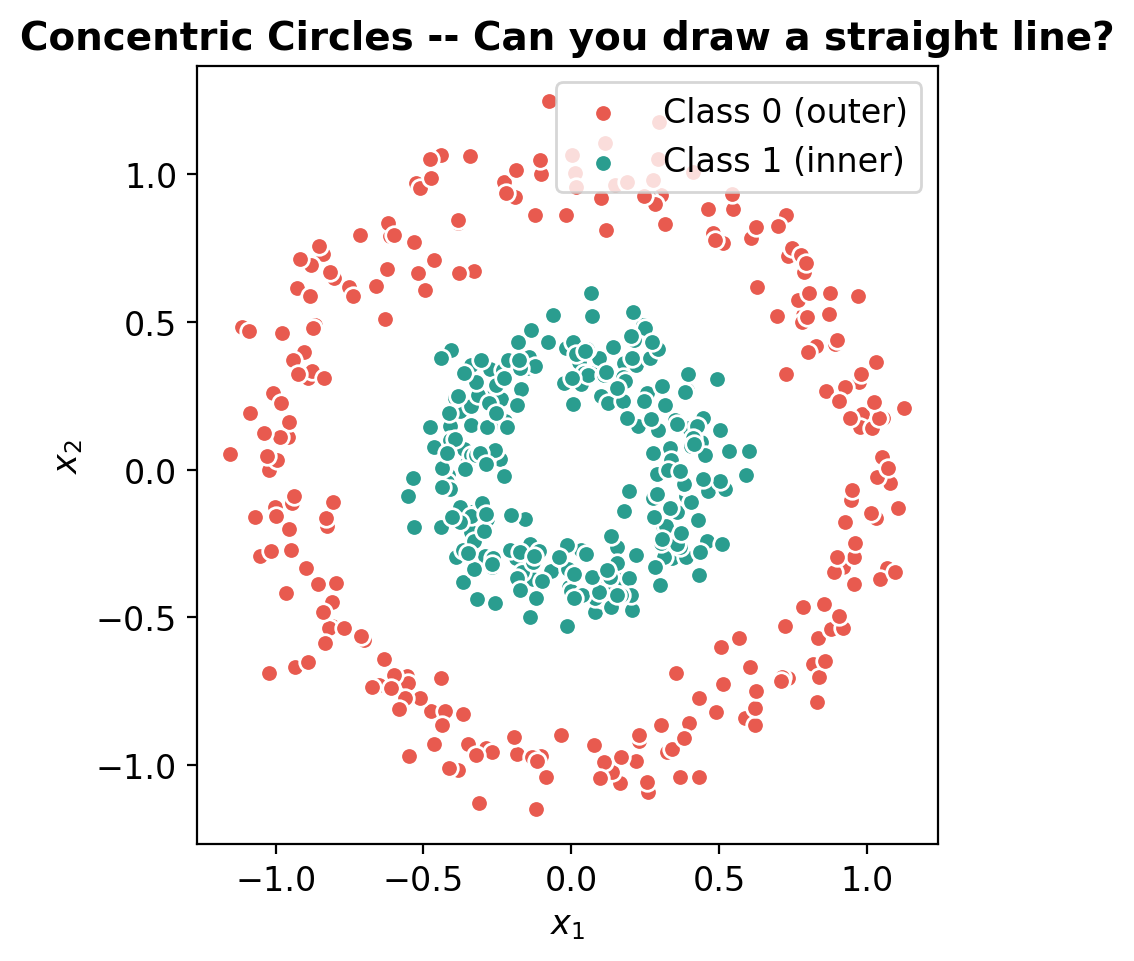

In [3]:
# Generate concentric circles
np.random.seed(42)
X_circles, y_circles = make_circles(n_samples=500, noise=0.08, factor=0.4)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], 
           c=C0, edgecolors='white', s=40, label='Class 0 (outer)')
ax.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], 
           c=C1, edgecolors='white', s=40, label='Class 1 (inner)')
ax.set_title('Concentric Circles -- Can you draw a straight line?', fontsize=14, fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Step 1: Logistic Regression (sklearn)

A straight line through this data. Will it work?

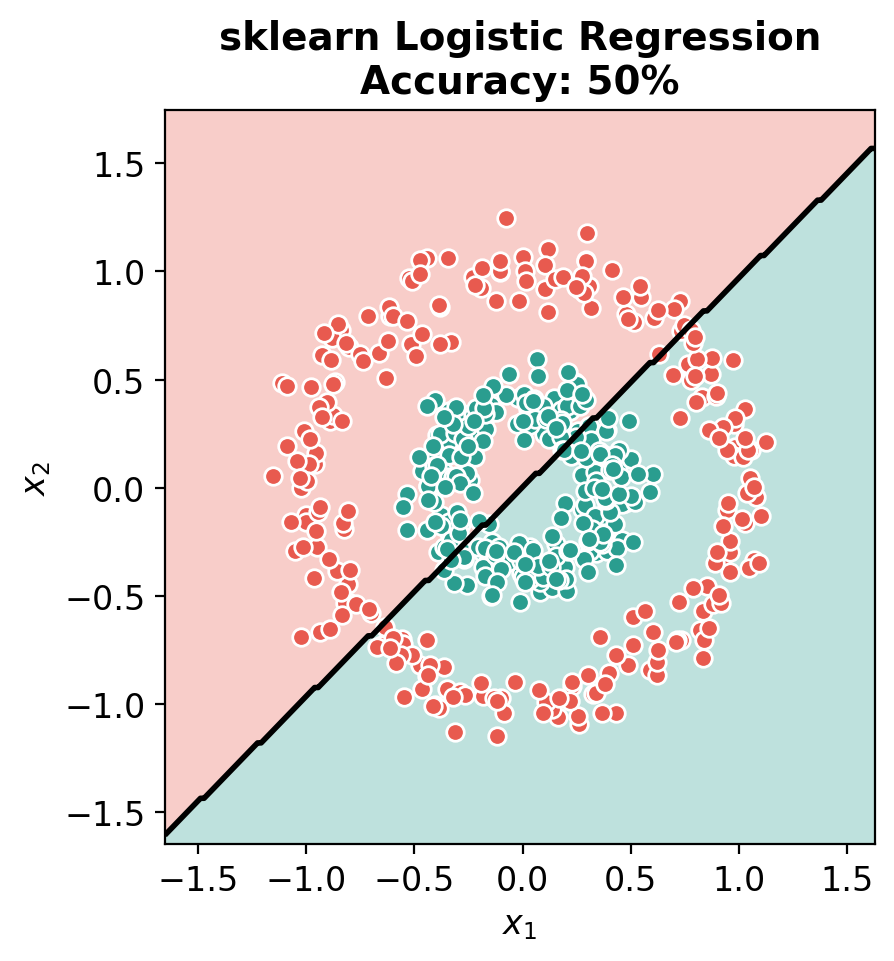

Accuracy: 50% -- basically random guessing!
A straight line cannot separate circles.


In [4]:
# Logistic regression = straight line decision boundary
lr_sklearn = LogisticRegression()
lr_sklearn.fit(X_circles, y_circles)

acc = lr_sklearn.score(X_circles, y_circles)

fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_boundary(lr_sklearn.predict, X_circles, y_circles,
                       f'sklearn Logistic Regression\nAccuracy: {acc:.0%}', ax=ax)
plt.tight_layout()
plt.show()

print(f'Accuracy: {acc:.0%} -- basically random guessing!')
print('A straight line cannot separate circles.')

### Step 2: Logistic Regression in PyTorch

Same thing, but written in PyTorch. Same result -- just to show how PyTorch works.

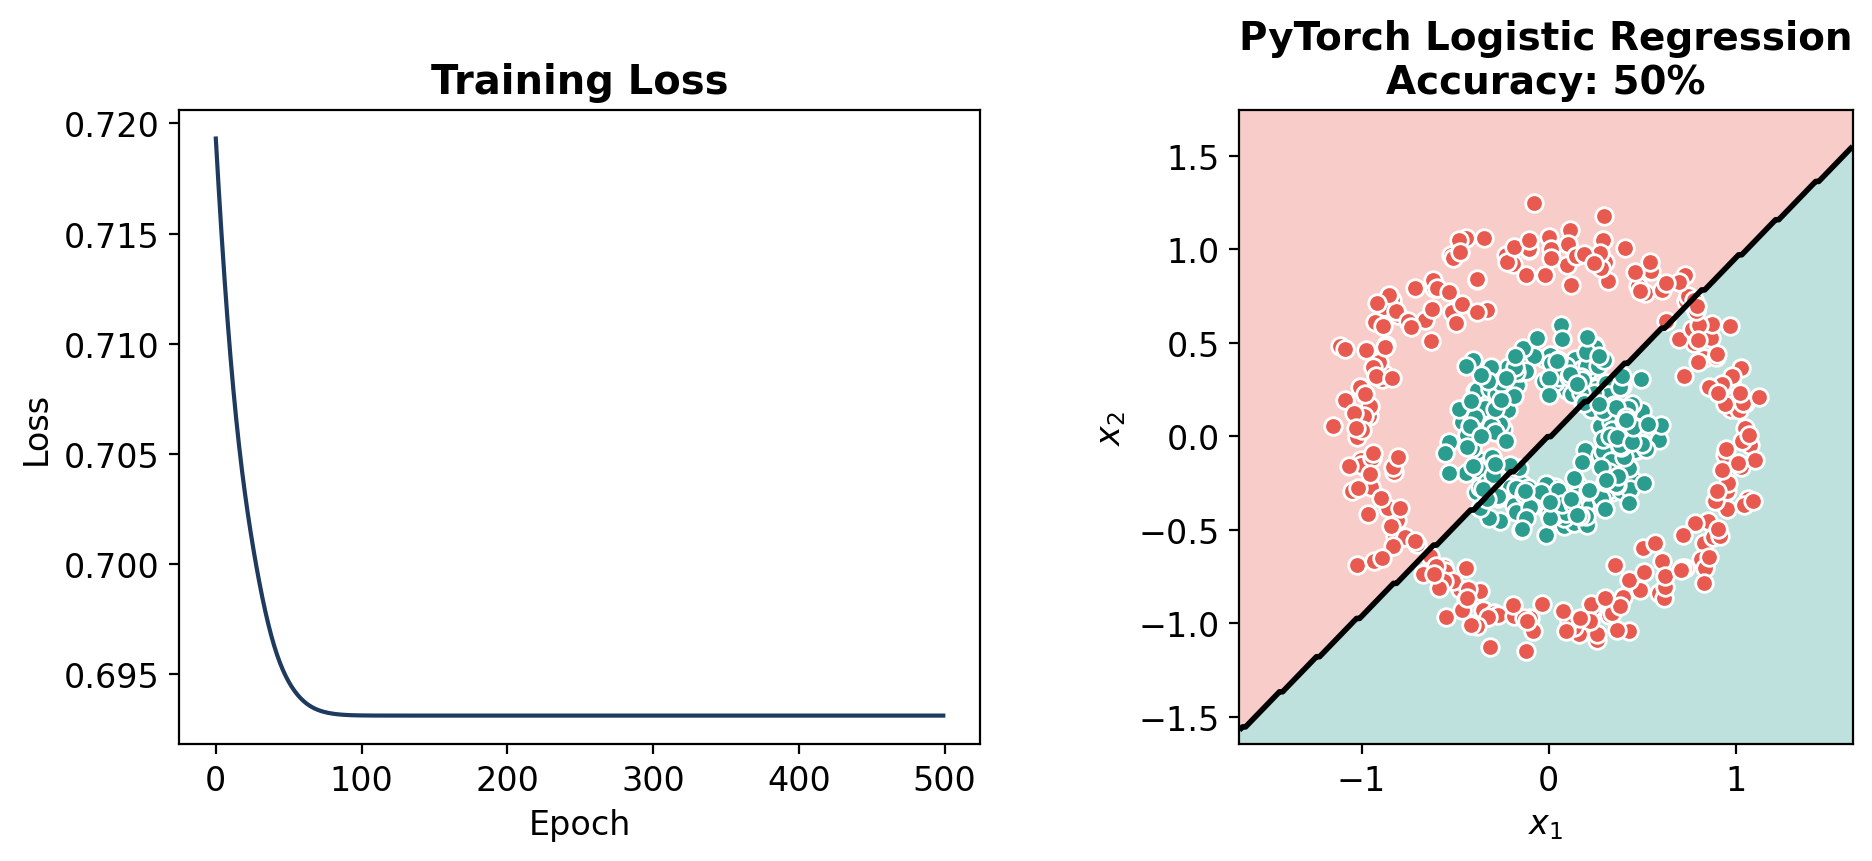

Same result! Accuracy: 50%
PyTorch logistic regression = sklearn logistic regression. Both are linear.


In [5]:
# Convert data to tensors
X_t = torch.tensor(X_circles, dtype=torch.float32)
y_t = torch.tensor(y_circles, dtype=torch.float32).unsqueeze(1)

# Logistic regression in PyTorch = Linear layer + Sigmoid
torch.manual_seed(42)
logreg_torch = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(logreg_torch.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

# Train
losses = []
for epoch in range(500):
    pred = logreg_torch(X_t)
    loss = loss_fn(pred, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Predict function for plotting
def predict_logreg_torch(X_np):
    with torch.no_grad():
        probs = logreg_torch(torch.tensor(X_np, dtype=torch.float32))
        return (probs.numpy() > 0.5).astype(int).ravel()

acc = (predict_logreg_torch(X_circles) == y_circles).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].plot(losses, color='#1e3a5f')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')

plot_decision_boundary(predict_logreg_torch, X_circles, y_circles,
                       f'PyTorch Logistic Regression\nAccuracy: {acc:.0%}', ax=axes[1])
plt.tight_layout()
plt.show()

print(f'Same result! Accuracy: {acc:.0%}')
print('PyTorch logistic regression = sklearn logistic regression. Both are linear.')

### Step 3: Basis Expansion -- The Manual Fix

**Key idea:** The data isn't linearly separable in $(x_1, x_2)$ space. But what if we add new features?

For circles, the separating boundary is $x_1^2 + x_2^2 = r^2$. So let's add $x_1^2$, $x_2^2$, $x_1 x_2$ as features!

This is called **basis expansion** or **feature engineering** -- we manually create the right features.

Original features: 2 -- (x1, x2)
After basis expansion: 5 -- (x0 , x1 , x0^2 , x0 x1 , x1^2)



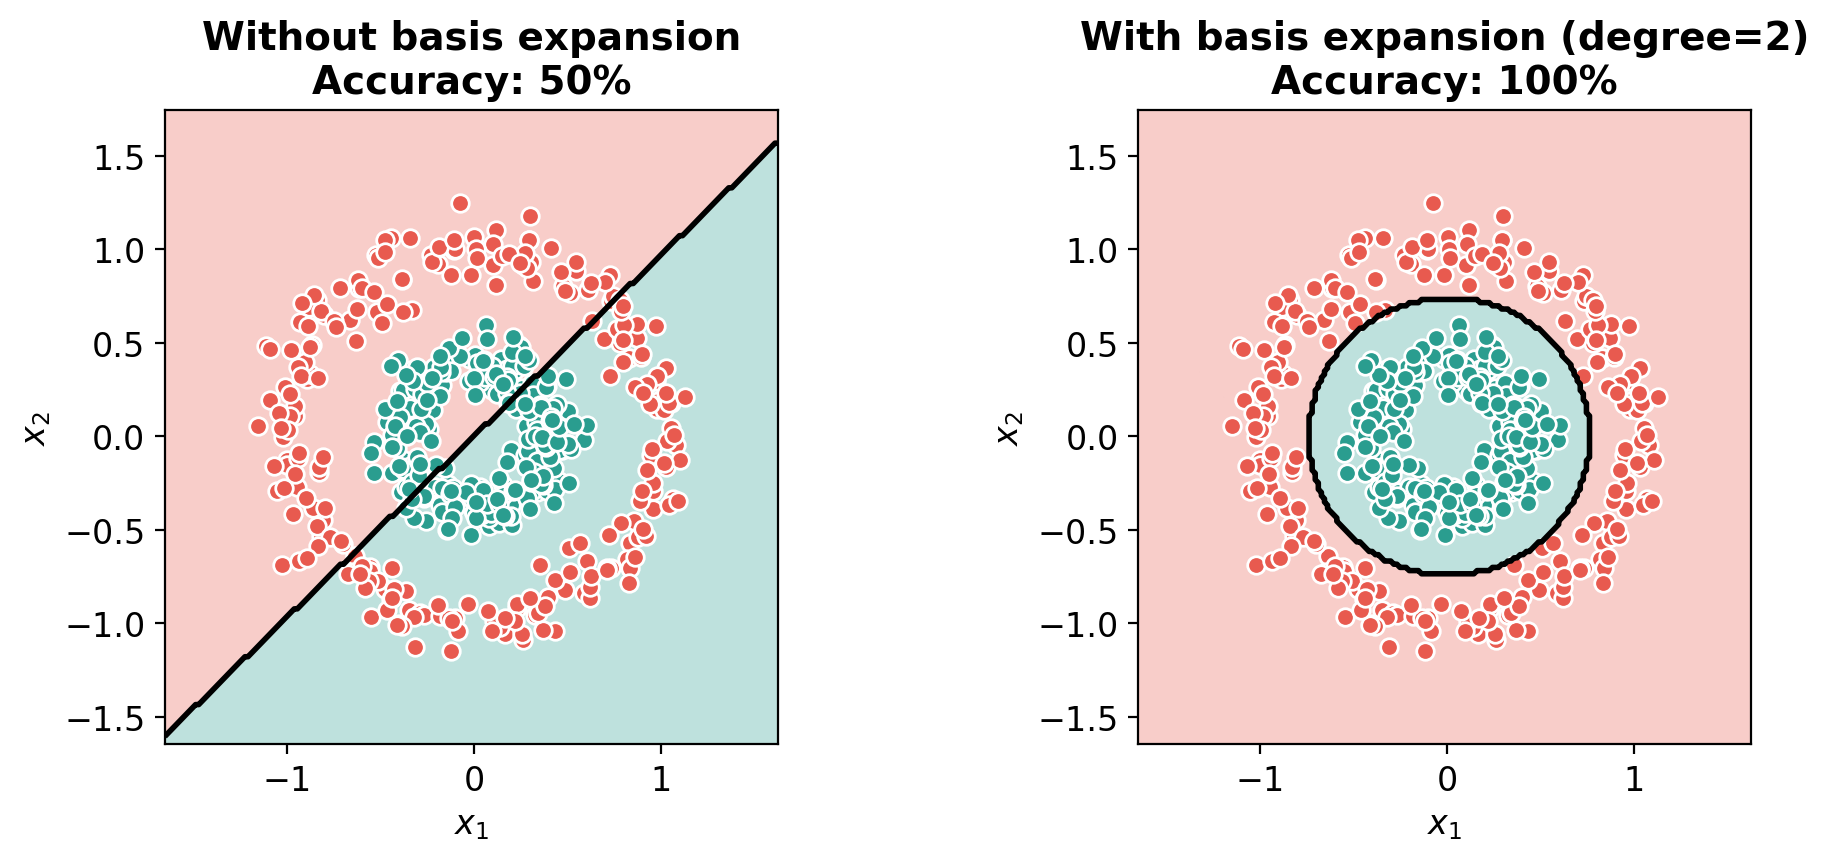

Accuracy with basis expansion: 100%
It works! But we had to KNOW to add x1^2, x2^2, x1*x2.


In [6]:
# Basis expansion: add polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_circles)

print(f'Original features: {X_circles.shape[1]} -- (x1, x2)')
print(f'After basis expansion: {X_poly.shape[1]} -- ({" , ".join(poly.get_feature_names_out())})')
print()

# sklearn logistic regression on expanded features
lr_poly = LogisticRegression()
lr_poly.fit(X_poly, y_circles)

# For plotting, we need to transform the grid too
def predict_poly_sklearn(X_np):
    return lr_poly.predict(poly.transform(X_np))

acc = lr_poly.score(X_poly, y_circles)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_decision_boundary(lr_sklearn.predict, X_circles, y_circles,
                       f'Without basis expansion\nAccuracy: {lr_sklearn.score(X_circles, y_circles):.0%}', ax=axes[0])
plot_decision_boundary(predict_poly_sklearn, X_circles, y_circles,
                       f'With basis expansion (degree=2)\nAccuracy: {acc:.0%}', ax=axes[1])
plt.tight_layout()
plt.show()

print(f'Accuracy with basis expansion: {acc:.0%}')
print('It works! But we had to KNOW to add x1^2, x2^2, x1*x2.')

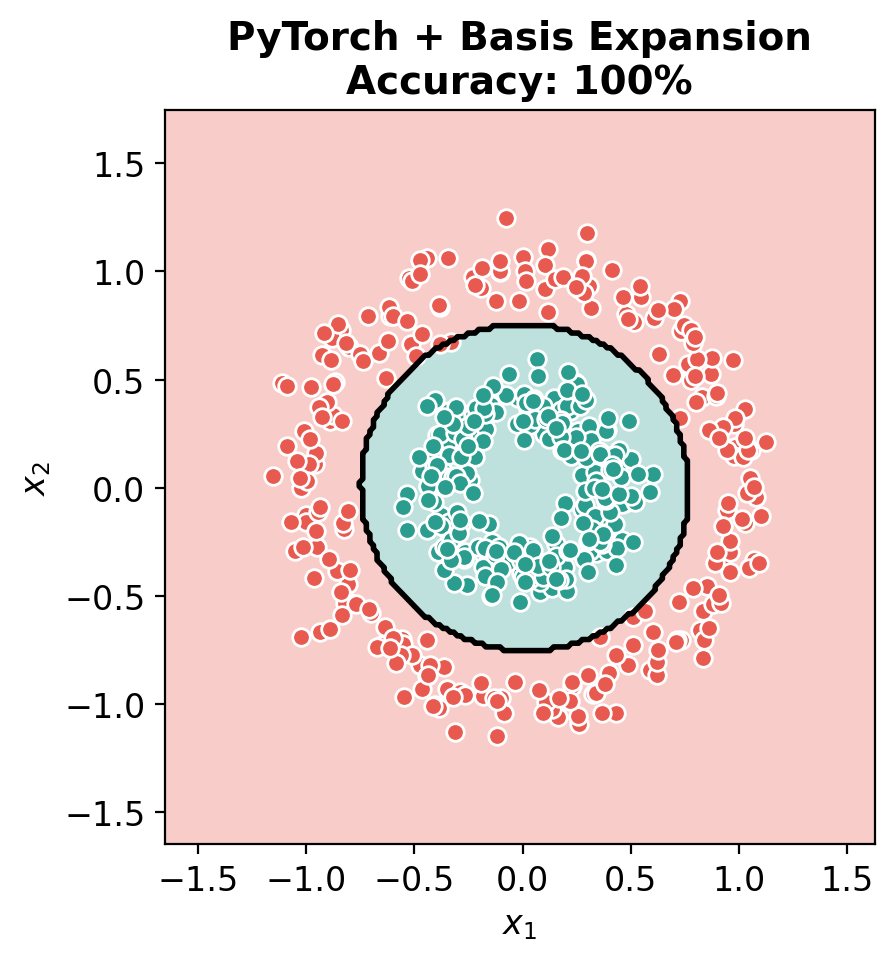

Same idea in PyTorch: 100%


In [7]:
# Same basis expansion, but logistic regression in PyTorch
X_poly_t = torch.tensor(X_poly, dtype=torch.float32)

torch.manual_seed(42)
logreg_poly_torch = nn.Sequential(
    nn.Linear(5, 1),   # 5 features after basis expansion
    nn.Sigmoid()
)

optimizer = optim.Adam(logreg_poly_torch.parameters(), lr=0.01)

for epoch in range(500):
    pred = logreg_poly_torch(X_poly_t)
    loss = loss_fn(pred, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

def predict_poly_torch(X_np):
    with torch.no_grad():
        X_p = torch.tensor(poly.transform(X_np), dtype=torch.float32)
        return (logreg_poly_torch(X_p).numpy() > 0.5).astype(int).ravel()

acc = (predict_poly_torch(X_circles) == y_circles).mean()

fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_boundary(predict_poly_torch, X_circles, y_circles,
                       f'PyTorch + Basis Expansion\nAccuracy: {acc:.0%}', ax=ax)
plt.tight_layout()
plt.show()

print(f'Same idea in PyTorch: {acc:.0%}')

### Step 4: Neural Network -- No Feature Engineering Needed!

**The magic:** A neural network on the *original* 2 features learns its own basis expansion.

No need to manually add $x_1^2$, $x_2^2$, etc. The hidden layers figure it out.

In [8]:
# Neural network -- on original (x1, x2) features, NO basis expansion
torch.manual_seed(42)
nn_model = nn.Sequential(
    nn.Linear(2, 16),    # 2 inputs -> 16 hidden neurons
    nn.ReLU(),
    nn.Linear(16, 16),   # 16 -> 16 hidden neurons
    nn.ReLU(),
    nn.Linear(16, 1),    # 16 -> 1 output
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model.parameters(), lr=0.01)

losses = []
for epoch in range(1000):
    pred = nn_model(X_t)
    loss = loss_fn(pred, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

def predict_nn(X_np):
    with torch.no_grad():
        probs = nn_model(torch.tensor(X_np, dtype=torch.float32))
        return (probs.numpy() > 0.5).astype(int).ravel()

acc = (predict_nn(X_circles) == y_circles).mean()
print(f'Neural Network Accuracy: {acc:.0%}')

Neural Network Accuracy: 100%


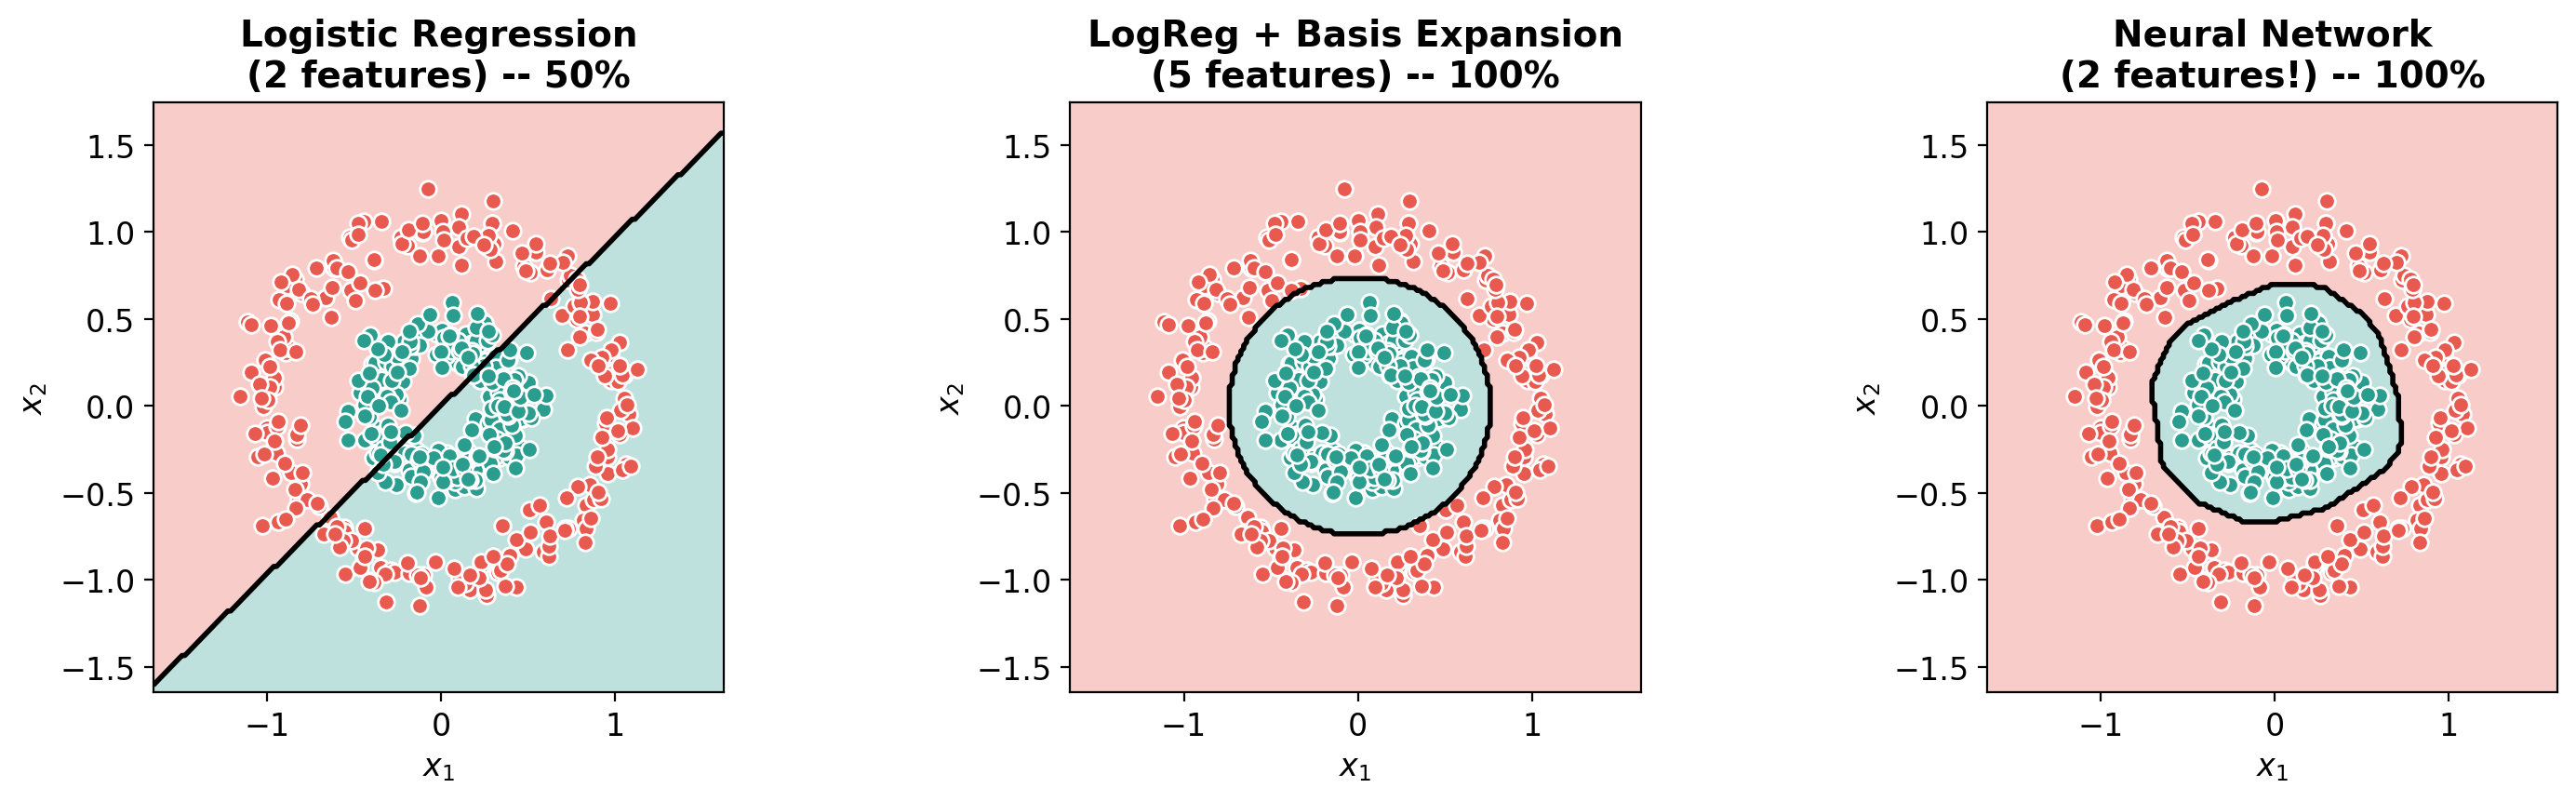

Left:   Linear model on raw features     -- FAILS (can only draw a line)
Middle: Linear model + manual features    -- WORKS (but we had to know which features to add)
Right:  Neural network on raw features    -- WORKS (learns its own features!)


In [9]:
# The big comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_decision_boundary(lr_sklearn.predict, X_circles, y_circles,
    f'Logistic Regression\n(2 features) -- {lr_sklearn.score(X_circles, y_circles):.0%}', ax=axes[0])

plot_decision_boundary(predict_poly_sklearn, X_circles, y_circles,
    f'LogReg + Basis Expansion\n(5 features) -- {lr_poly.score(X_poly, y_circles):.0%}', ax=axes[1])

plot_decision_boundary(predict_nn, X_circles, y_circles,
    f'Neural Network\n(2 features!) -- {acc:.0%}', ax=axes[2])

plt.tight_layout()
plt.show()

print('Left:   Linear model on raw features     -- FAILS (can only draw a line)')
print('Middle: Linear model + manual features    -- WORKS (but we had to know which features to add)')
print('Right:  Neural network on raw features    -- WORKS (learns its own features!)')

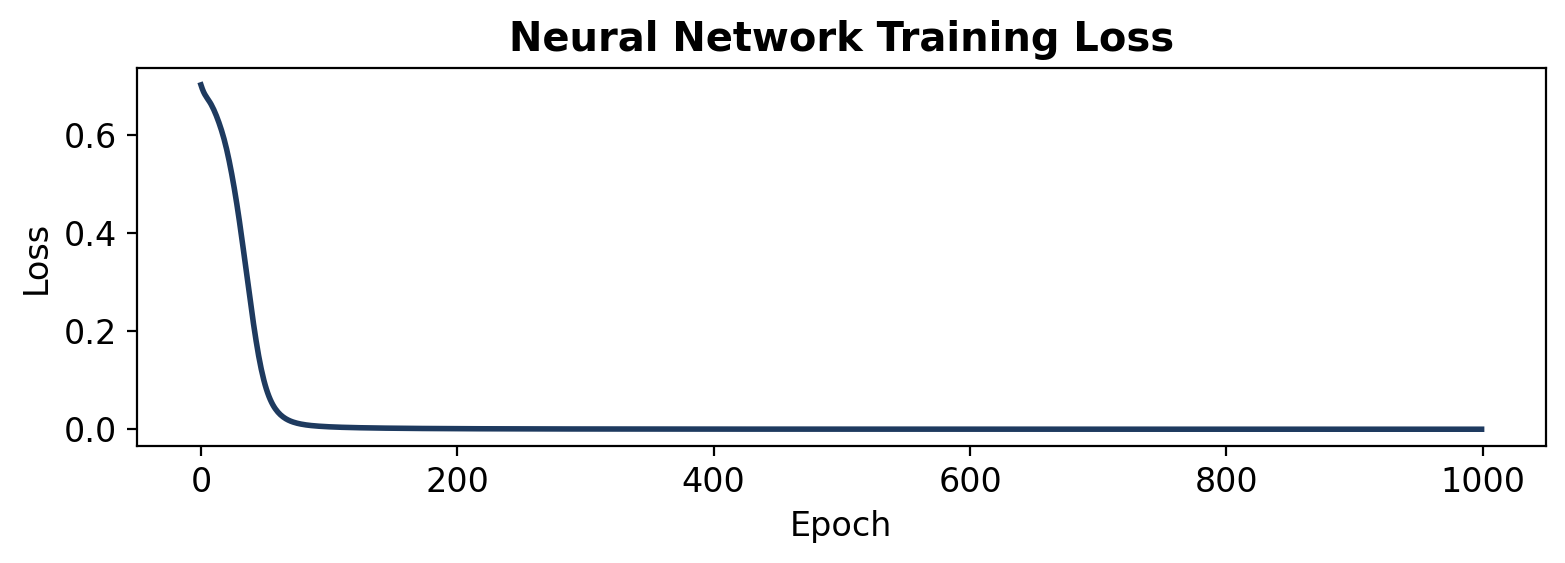

In [10]:
# Training loss curve for the neural network
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='#1e3a5f', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Neural Network Training Loss', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2: Regression -- Fitting a Wiggly Curve

Same idea, but for regression. Can a straight line fit a sine wave?

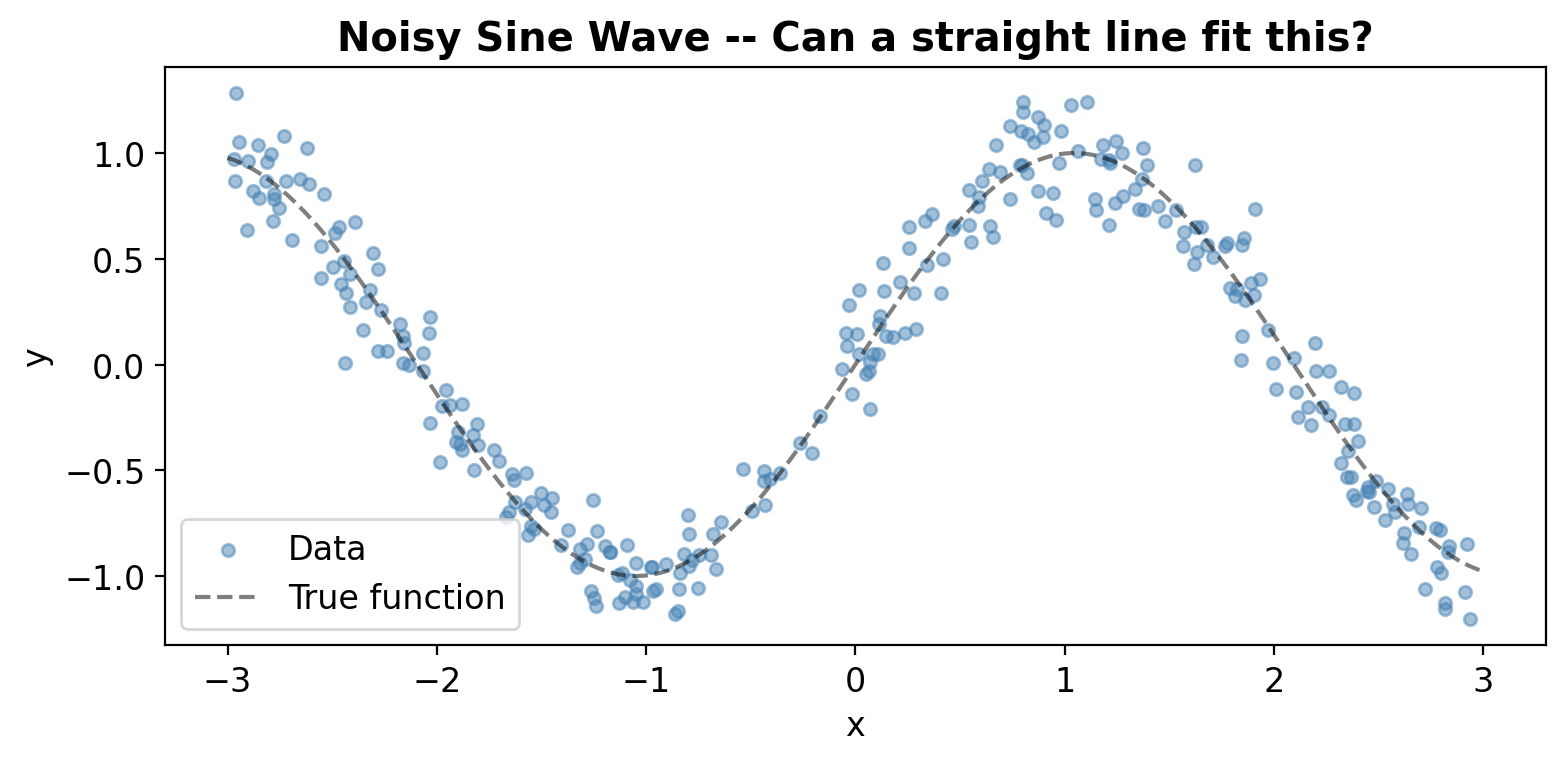

In [11]:
# Generate noisy sine wave data
np.random.seed(42)
n = 300
X_reg = np.sort(np.random.uniform(-3, 3, n))

# True function: a wiggly sine curve
def true_fn(x):
    return np.sin(1.5 * x)

y_reg = true_fn(X_reg) + np.random.normal(0, 0.15, n)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_reg, y_reg, alpha=0.5, s=20, color='steelblue', label='Data')
x_dense = np.linspace(-3, 3, 500)
ax.plot(x_dense, true_fn(x_dense), 'k--', alpha=0.5, label='True function')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Noisy Sine Wave -- Can a straight line fit this?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Step 1: Linear Regression (sklearn)

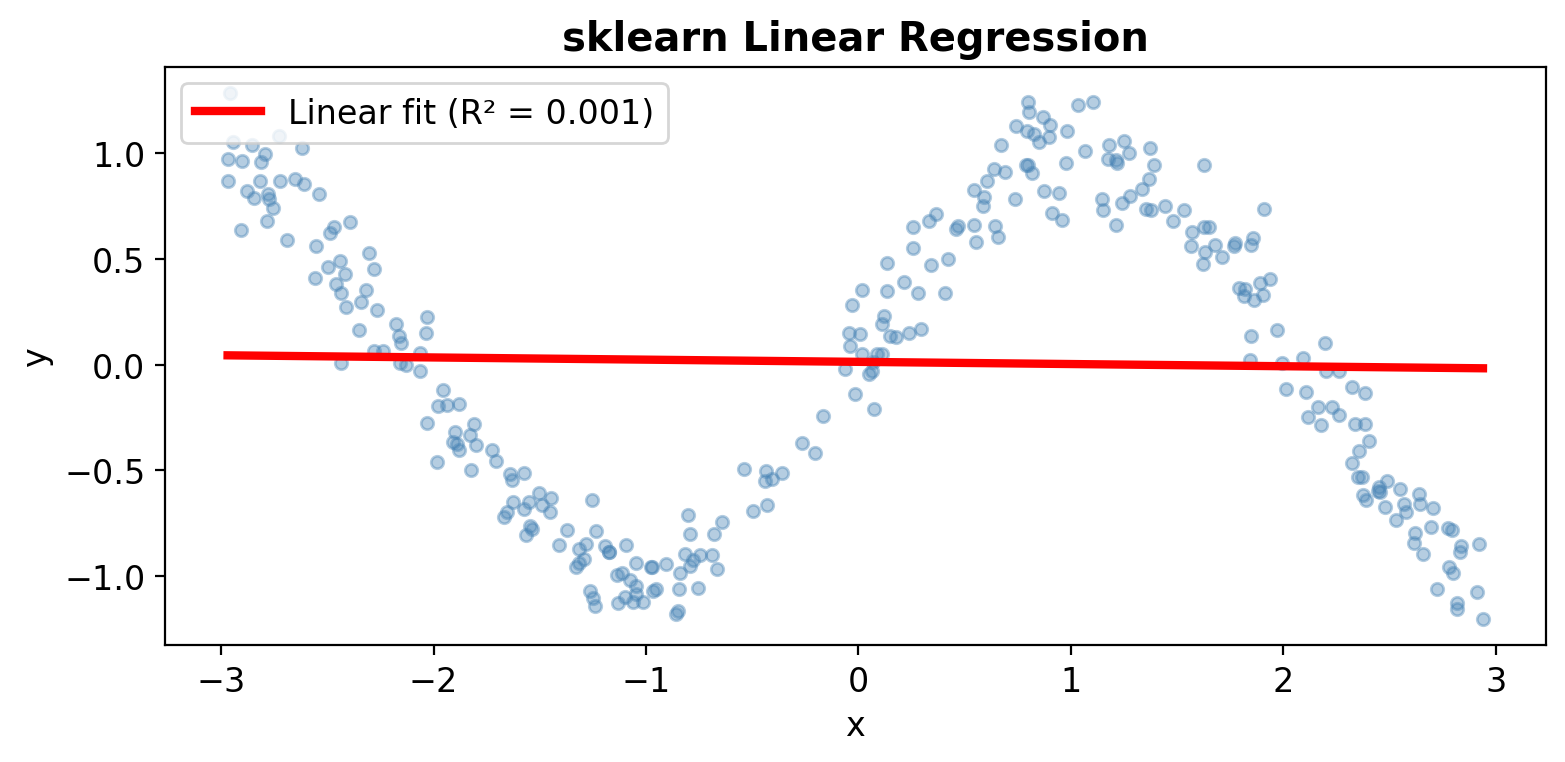

R² = 0.001 -- terrible! A line cannot capture the wiggles.


In [12]:
from sklearn.metrics import r2_score

# Fit a straight line
lin_sklearn = LinearRegression()
lin_sklearn.fit(X_reg.reshape(-1, 1), y_reg)
y_pred_lin = lin_sklearn.predict(X_reg.reshape(-1, 1))
r2_lin = r2_score(y_reg, y_pred_lin)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_reg, y_reg, alpha=0.4, s=20, color='steelblue')
ax.plot(X_reg, y_pred_lin, 'r-', linewidth=3, label=f'Linear fit (R² = {r2_lin:.3f})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('sklearn Linear Regression', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'R² = {r2_lin:.3f} -- terrible! A line cannot capture the wiggles.')

### Step 2: Linear Regression in PyTorch

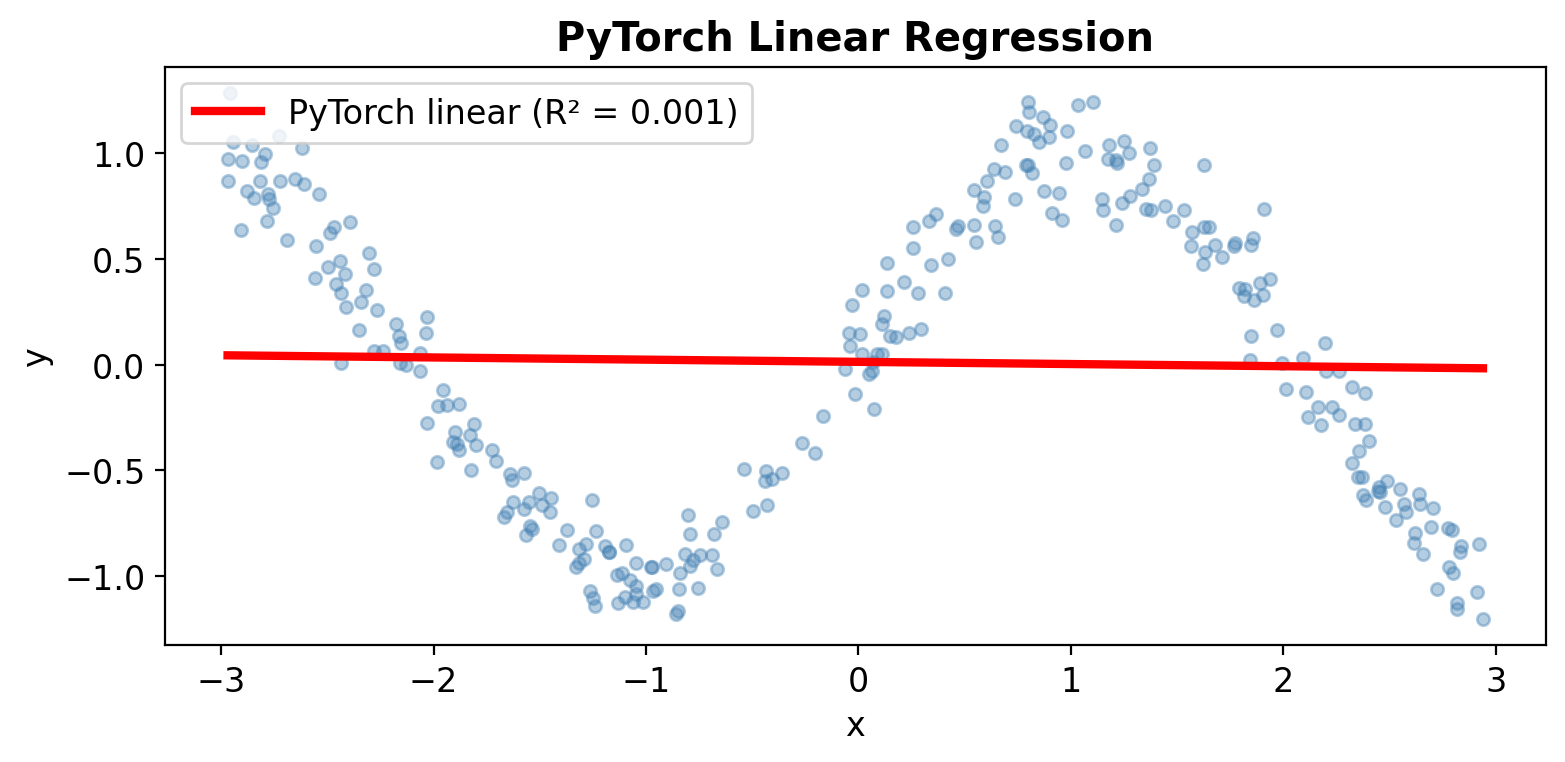

Same result: R² = 0.001
PyTorch linear = sklearn linear. Both can only fit a line.


In [13]:
# Same linear regression in PyTorch
X_reg_t = torch.tensor(X_reg, dtype=torch.float32).unsqueeze(1)
y_reg_t = torch.tensor(y_reg, dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
lin_torch = nn.Linear(1, 1)
optimizer = optim.Adam(lin_torch.parameters(), lr=0.05)
mse_loss = nn.MSELoss()

for epoch in range(500):
    pred = lin_torch(X_reg_t)
    loss = mse_loss(pred, y_reg_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred_lin_torch = lin_torch(X_reg_t).numpy()

r2_torch = r2_score(y_reg, y_pred_lin_torch)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_reg, y_reg, alpha=0.4, s=20, color='steelblue')
ax.plot(X_reg, y_pred_lin_torch, 'r-', linewidth=3, label=f'PyTorch linear (R² = {r2_torch:.3f})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('PyTorch Linear Regression', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Same result: R² = {r2_torch:.3f}')
print('PyTorch linear = sklearn linear. Both can only fit a line.')

### Step 3: Basis Expansion -- Adding Polynomial Features

Original: 1 feature (x)
After expansion: 5 features (x0 , x0^2 , x0^3 , x0^4 , x0^5)



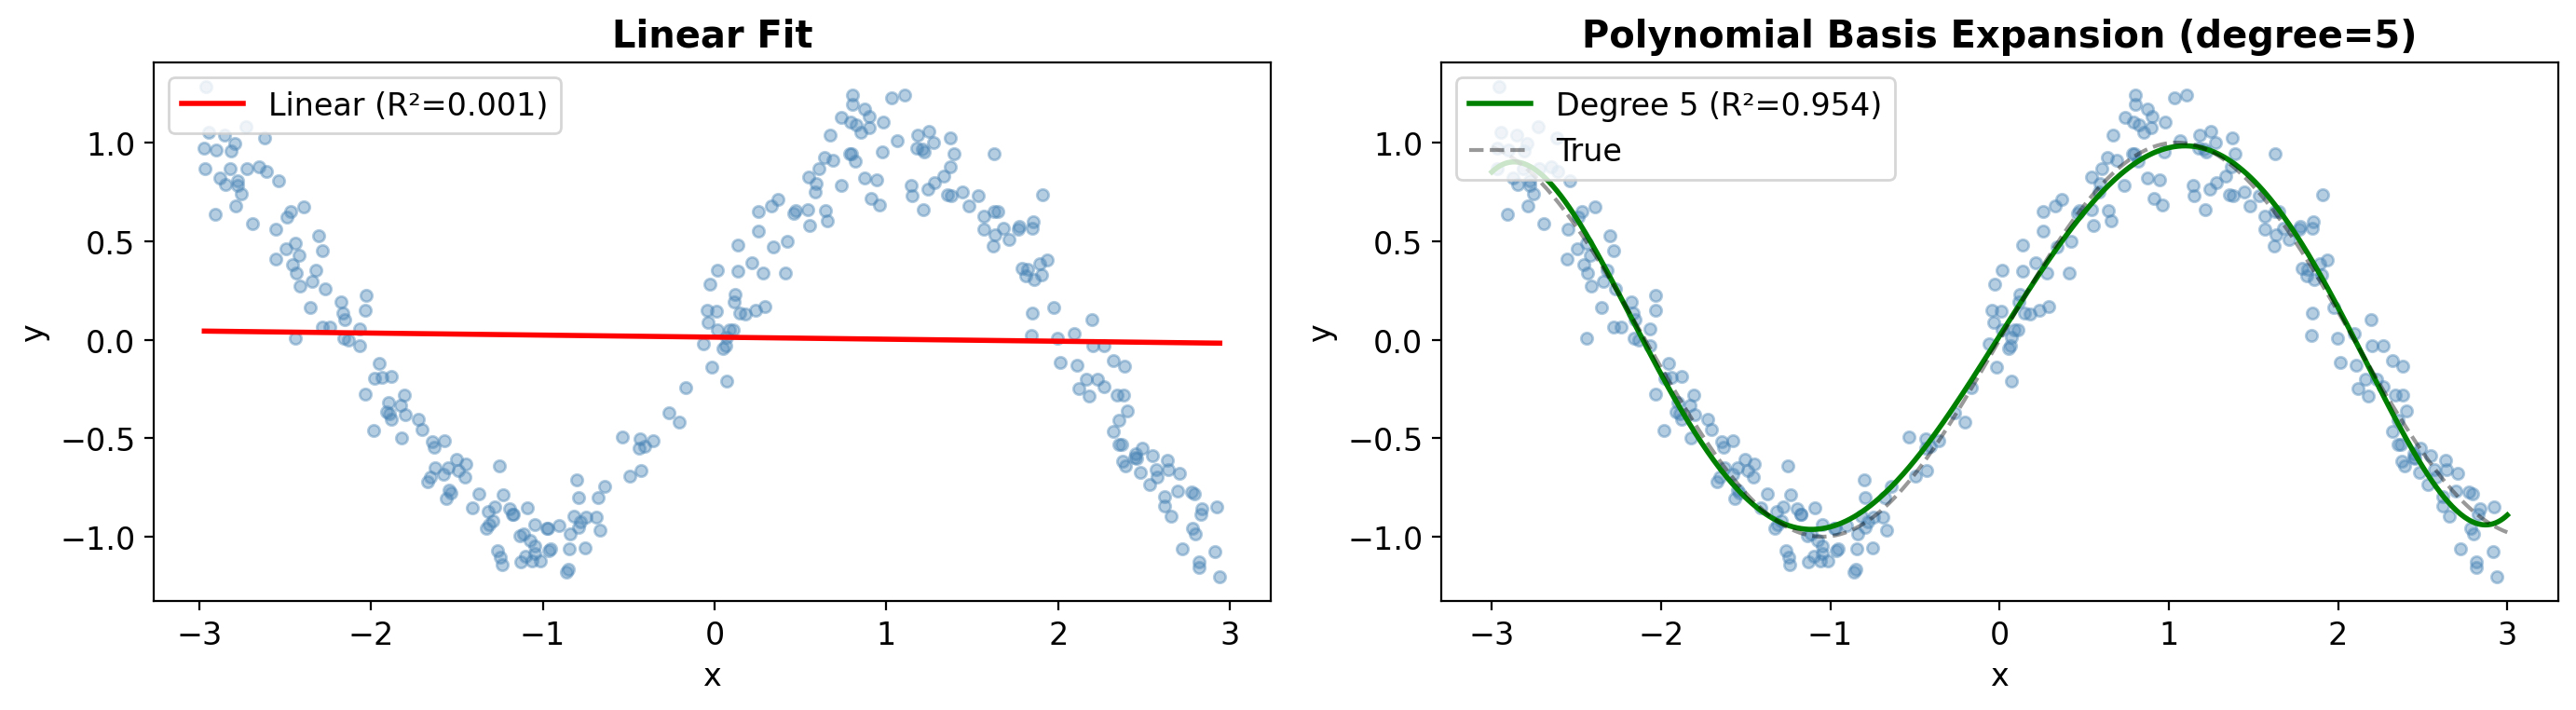

With basis expansion: R² = 0.954
It works! But we had to guess that degree=5 was right.


In [14]:
# Basis expansion: add x^2, x^3, x^4, x^5
poly_reg = PolynomialFeatures(degree=5, include_bias=False)
X_reg_poly = poly_reg.fit_transform(X_reg.reshape(-1, 1))

print(f'Original: 1 feature (x)')
print(f'After expansion: {X_reg_poly.shape[1]} features ({" , ".join(poly_reg.get_feature_names_out())})')
print()

# sklearn
lin_poly_sklearn = LinearRegression()
lin_poly_sklearn.fit(X_reg_poly, y_reg)

x_dense_poly = poly_reg.transform(x_dense.reshape(-1, 1))
y_pred_poly = lin_poly_sklearn.predict(x_dense_poly)
r2_poly = r2_score(y_reg, lin_poly_sklearn.predict(X_reg_poly))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(X_reg, y_reg, alpha=0.4, s=20, color='steelblue')
axes[0].plot(X_reg, y_pred_lin, 'r-', linewidth=2, label=f'Linear (R²={r2_lin:.3f})')
axes[0].set_title('Linear Fit', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

axes[1].scatter(X_reg, y_reg, alpha=0.4, s=20, color='steelblue')
axes[1].plot(x_dense, y_pred_poly, 'g-', linewidth=2, label=f'Degree 5 (R²={r2_poly:.3f})')
axes[1].plot(x_dense, true_fn(x_dense), 'k--', alpha=0.4, label='True')
axes[1].set_title('Polynomial Basis Expansion (degree=5)', fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

print(f'With basis expansion: R² = {r2_poly:.3f}')
print('It works! But we had to guess that degree=5 was right.')

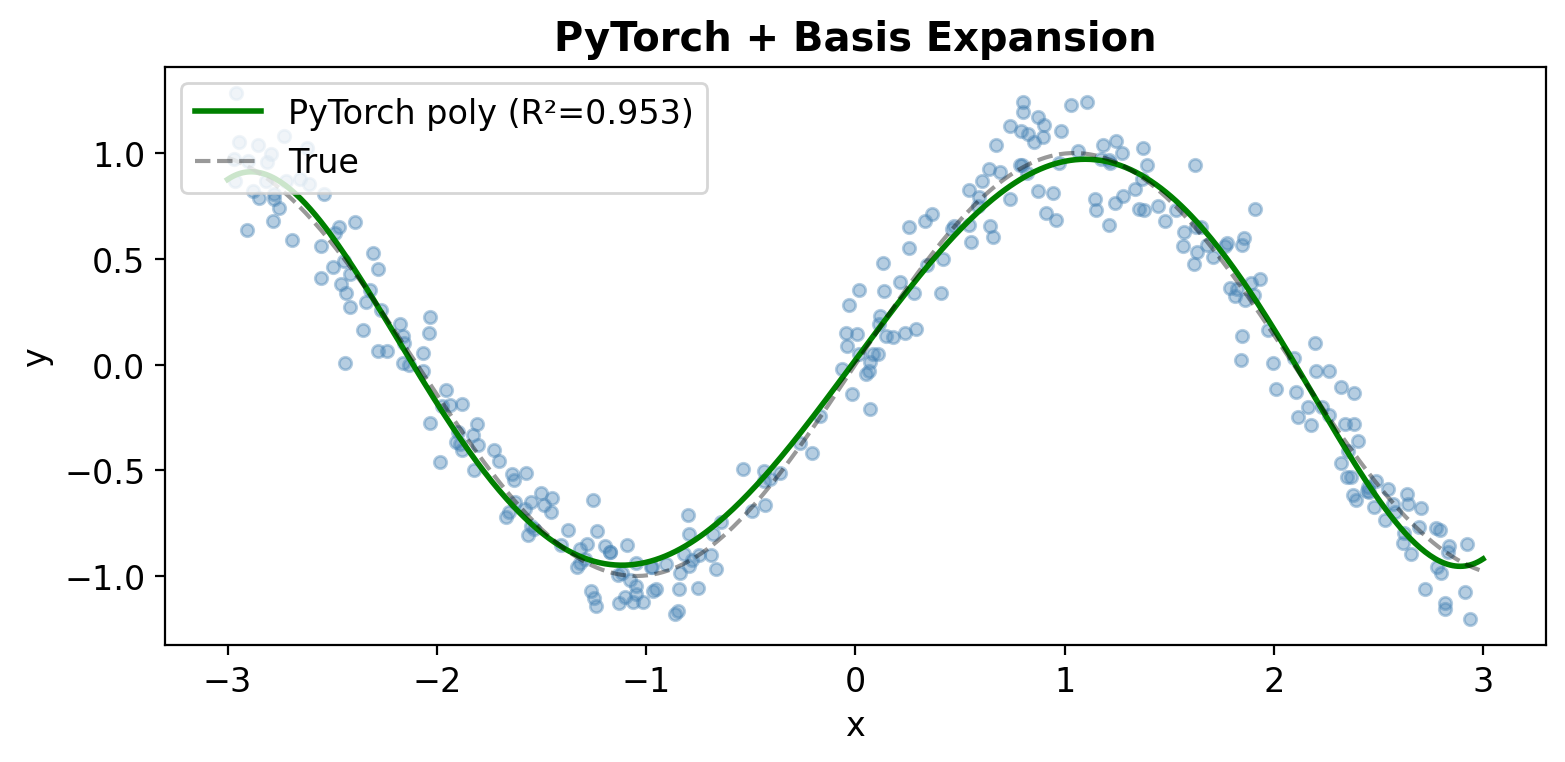

In [15]:
# Same in PyTorch
X_reg_poly_t = torch.tensor(X_reg_poly, dtype=torch.float32)

torch.manual_seed(42)
lin_poly_torch = nn.Linear(5, 1)
optimizer = optim.Adam(lin_poly_torch.parameters(), lr=0.05)

for epoch in range(1000):
    pred = lin_poly_torch(X_reg_poly_t)
    loss = mse_loss(pred, y_reg_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    x_dense_t = torch.tensor(x_dense_poly, dtype=torch.float32)
    y_pred_poly_torch = lin_poly_torch(x_dense_t).numpy()
    r2_pt = r2_score(y_reg, lin_poly_torch(X_reg_poly_t).numpy())

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_reg, y_reg, alpha=0.4, s=20, color='steelblue')
ax.plot(x_dense, y_pred_poly_torch, 'g-', linewidth=2, label=f'PyTorch poly (R²={r2_pt:.3f})')
ax.plot(x_dense, true_fn(x_dense), 'k--', alpha=0.4, label='True')
ax.set_title('PyTorch + Basis Expansion', fontweight='bold')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

### Step 4: Neural Network -- Learns the Curve Automatically

In [16]:
# Neural network on original 1 feature -- NO basis expansion
torch.manual_seed(42)
nn_reg = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

optimizer = optim.Adam(nn_reg.parameters(), lr=0.01)

losses = []
for epoch in range(2000):
    pred = nn_reg(X_reg_t)
    loss = mse_loss(pred, y_reg_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

with torch.no_grad():
    x_dense_t1 = torch.tensor(x_dense, dtype=torch.float32).unsqueeze(1)
    y_pred_nn = nn_reg(x_dense_t1).numpy()
    r2_nn = r2_score(y_reg, nn_reg(X_reg_t).numpy())

print(f'Neural Network R² = {r2_nn:.3f}')

Neural Network R² = 0.959


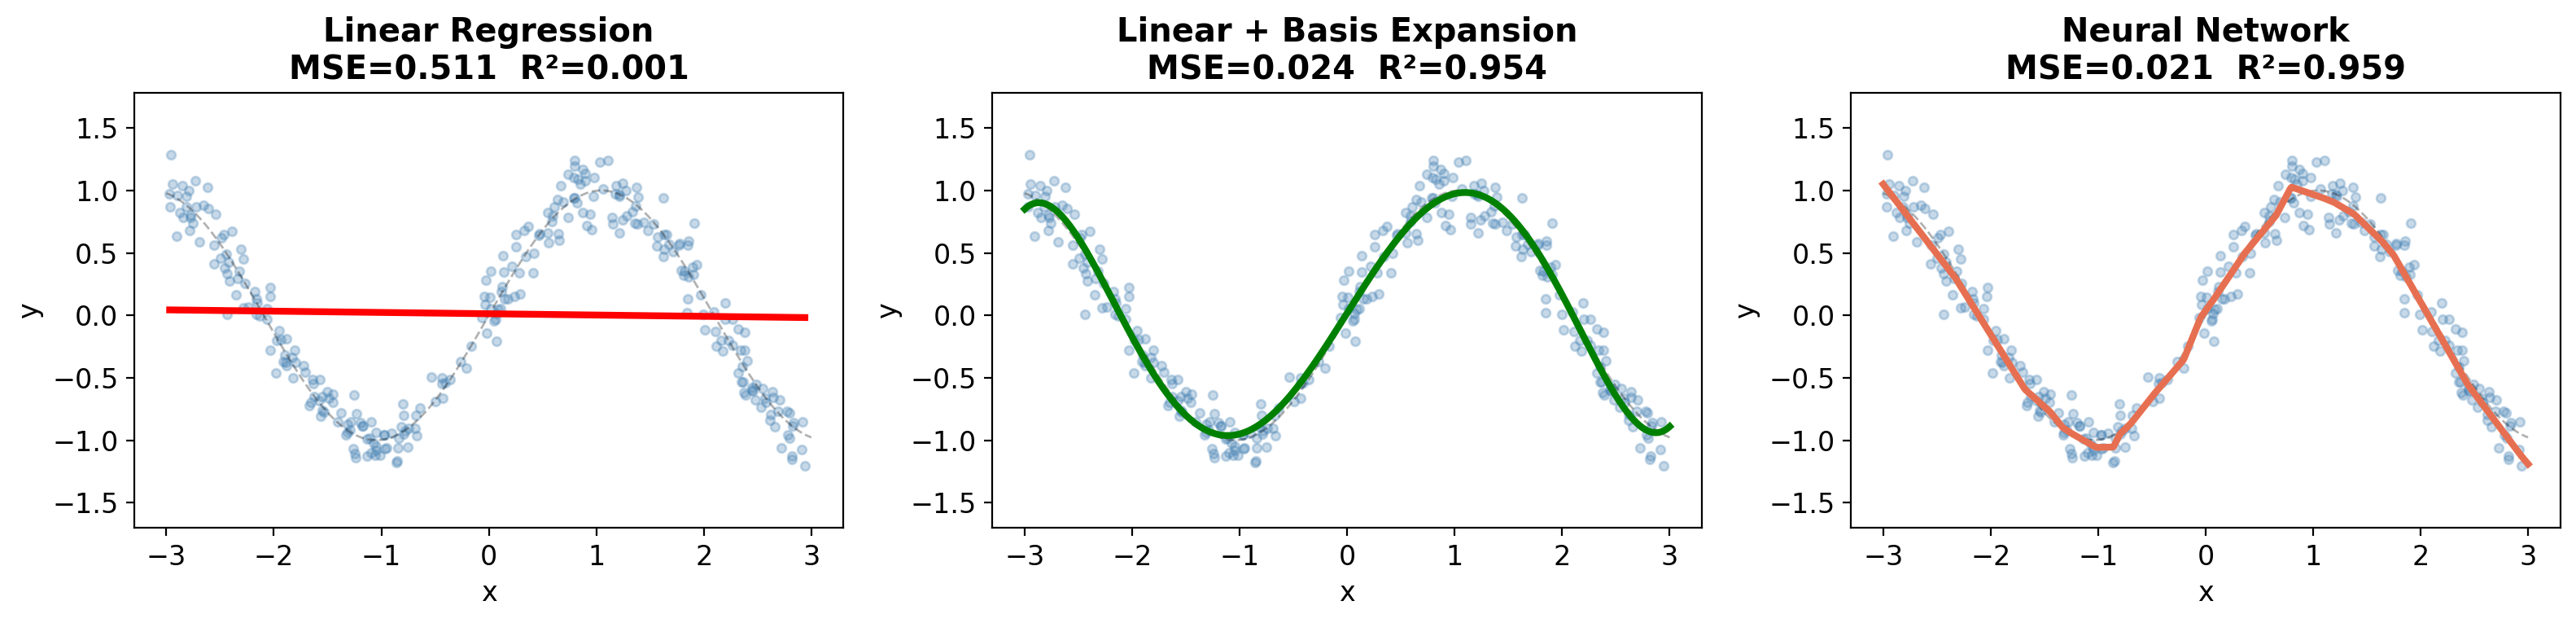

Model                               MSE       R²
------------------------------------------------
Linear (1 feature)               0.5111    0.001
Linear + poly features (5)       0.0238    0.954
Neural network (1 feature!)      0.0211    0.959


In [17]:
from sklearn.metrics import mean_squared_error

# Compute MSE for all models
with torch.no_grad():
    mse_lin = mean_squared_error(y_reg, y_pred_lin)
    mse_poly = mean_squared_error(y_reg, lin_poly_sklearn.predict(X_reg_poly))
    mse_nn = mean_squared_error(y_reg, nn_reg(X_reg_t).numpy())

# The big regression comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax in axes:
    ax.scatter(X_reg, y_reg, alpha=0.3, s=15, color='steelblue')
    ax.plot(x_dense, true_fn(x_dense), 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_ylim(y_reg.min() - 0.5, y_reg.max() + 0.5)

axes[0].plot(X_reg, y_pred_lin, 'r-', linewidth=3)
axes[0].set_title(f'Linear Regression\nMSE={mse_lin:.3f}  R²={r2_lin:.3f}', fontweight='bold')

axes[1].plot(x_dense, y_pred_poly, 'g-', linewidth=3)
axes[1].set_title(f'Linear + Basis Expansion\nMSE={mse_poly:.3f}  R²={r2_poly:.3f}', fontweight='bold')

axes[2].plot(x_dense, y_pred_nn.ravel(), '#e76f51', linewidth=3)
axes[2].set_title(f'Neural Network\nMSE={mse_nn:.3f}  R²={r2_nn:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'{"Model":<30} {"MSE":>8} {"R²":>8}')
print('-' * 48)
print(f'{"Linear (1 feature)":<30} {mse_lin:>8.4f} {r2_lin:>8.3f}')
print(f'{"Linear + poly features (5)":<30} {mse_poly:>8.4f} {r2_poly:>8.3f}')
print(f'{"Neural network (1 feature!)":<30} {mse_nn:>8.4f} {r2_nn:>8.3f}')

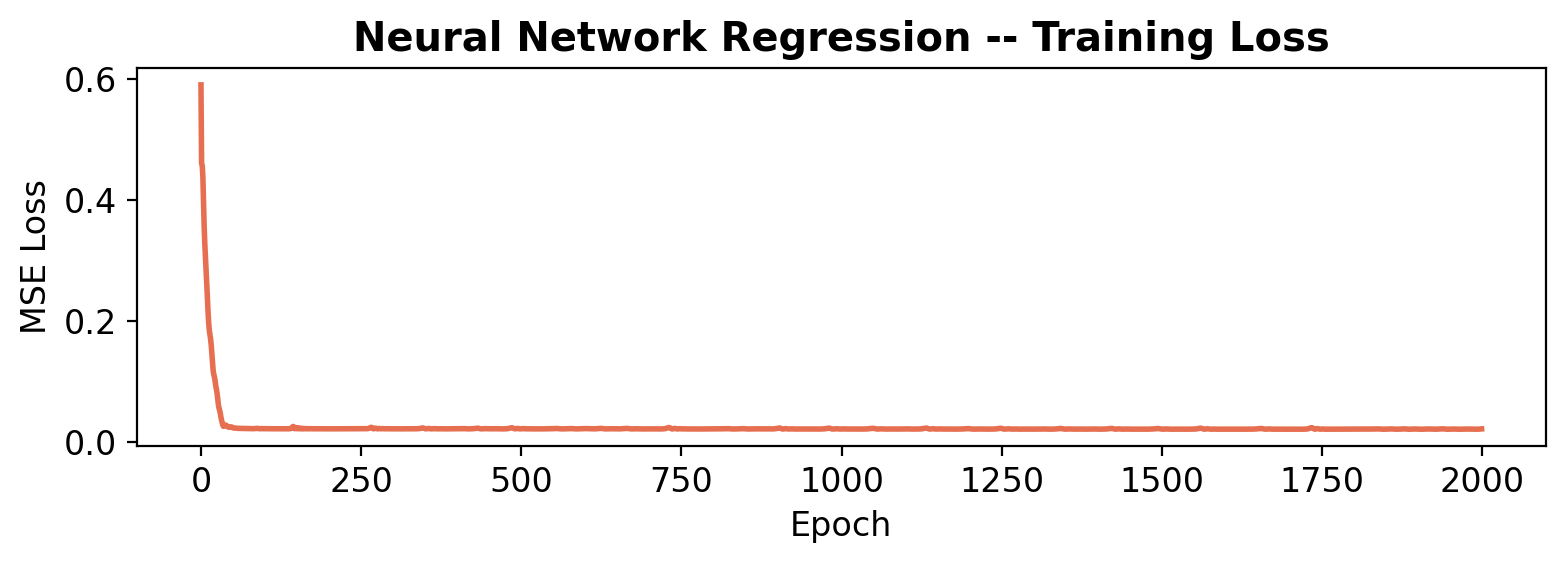

In [18]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='#e76f51', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network Regression -- Training Loss', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Interim Takeaway

| Approach | Features | Works? | Problem |
|----------|----------|--------|---------|
| Linear model | Raw $(x_1, x_2)$ | No | Can only draw straight lines |
| Linear model + basis expansion | Manual $(x_1, x_2, x_1^2, x_2^2, ...)$ | Yes | You must **know** which features to add |
| Neural network | Raw $(x_1, x_2)$ | Yes | Learns its own features automatically! |

But those were easy examples. What about harder data where you *can't* guess the right features?

---
## Part 3: When Feature Engineering Breaks Down -- Spirals

Concentric circles were "easy" -- we knew the boundary was $x_1^2 + x_2^2 = r^2$.

What about data where you have **no idea** what features to add?

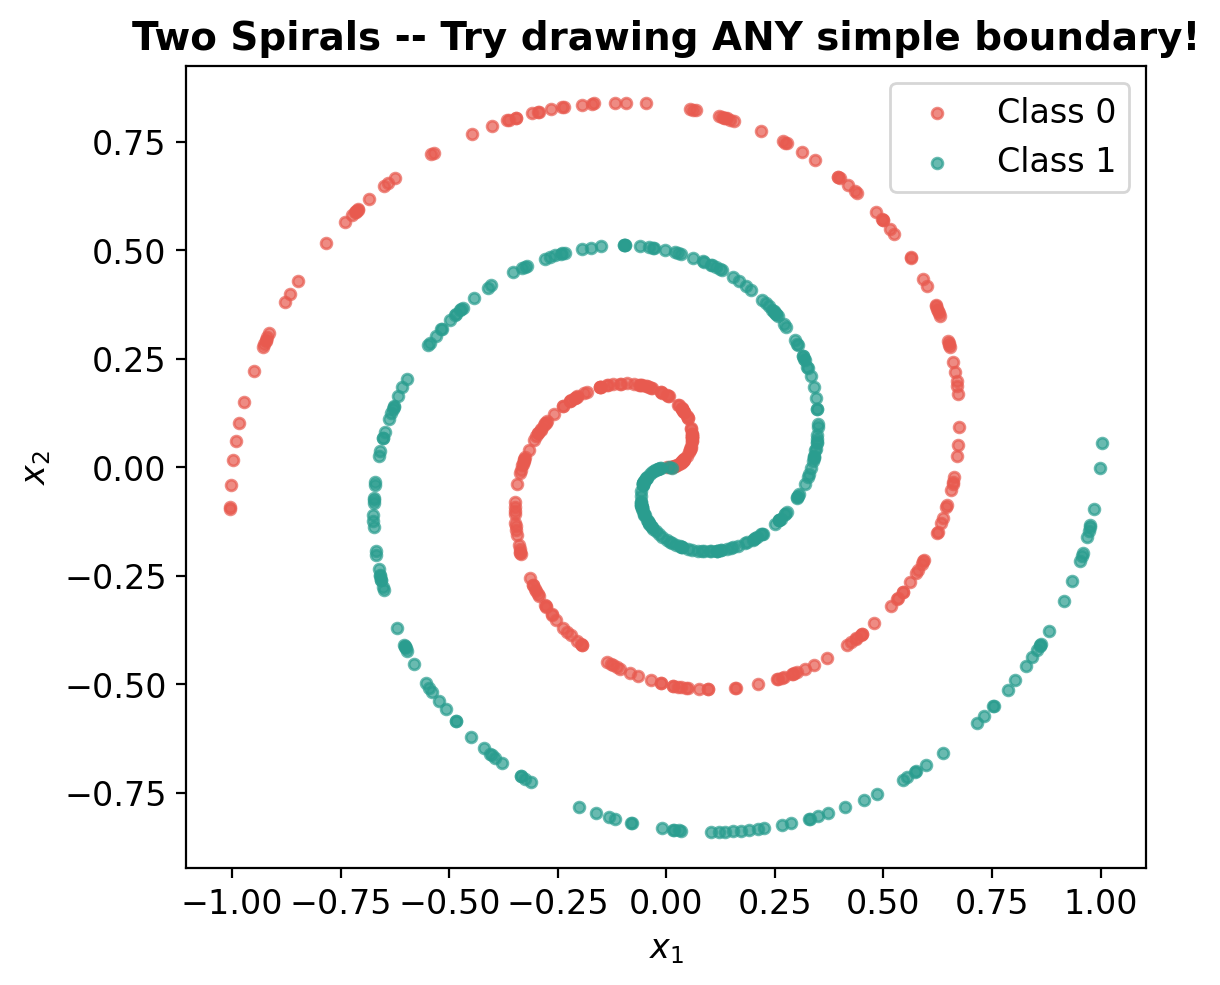

No polynomial, no simple formula can separate these spirals.
You would need to engineer very exotic features (polar coords, angles, etc.)


In [19]:
# Generate spiral data -- much harder than circles!
np.random.seed(42)
n_per_class = 300

theta0 = np.linspace(0, 3 * np.pi, n_per_class) + np.random.normal(0, 0.15, n_per_class)
r0 = theta0 / (3 * np.pi)
x0 = np.c_[r0 * np.cos(theta0), r0 * np.sin(theta0)]

theta1 = np.linspace(0, 3 * np.pi, n_per_class) + np.random.normal(0, 0.15, n_per_class)
r1 = theta1 / (3 * np.pi)
x1 = np.c_[r1 * np.cos(theta1 + np.pi), r1 * np.sin(theta1 + np.pi)]

X_spiral = np.vstack([x0, x1])
y_spiral = np.array([0] * n_per_class + [1] * n_per_class)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1], c=C0, s=15, alpha=0.7, label='Class 0')
ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1], c=C1, s=15, alpha=0.7, label='Class 1')
ax.set_title('Two Spirals -- Try drawing ANY simple boundary!', fontsize=14, fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print('No polynomial, no simple formula can separate these spirals.')
print('You would need to engineer very exotic features (polar coords, angles, etc.)')

In [20]:
# Try everything we know: logistic regression, polynomial basis expansion, neural network
from sklearn.pipeline import make_pipeline

# 1. Logistic regression (linear)
lr_spiral = LogisticRegression()
lr_spiral.fit(X_spiral, y_spiral)

# 2. Polynomial basis expansion -- even degree 6 won't cut it
poly_spiral = PolynomialFeatures(degree=6, include_bias=False)
X_spiral_poly = poly_spiral.fit_transform(X_spiral)
lr_spiral_poly = LogisticRegression(max_iter=5000, C=10)
lr_spiral_poly.fit(X_spiral_poly, y_spiral)

print(f'Polynomial features: {X_spiral_poly.shape[1]} features from degree-6 expansion!')

def predict_spiral_poly(X_np):
    return lr_spiral_poly.predict(poly_spiral.transform(X_np))

# 3. Neural network
X_spiral_t = torch.tensor(X_spiral, dtype=torch.float32)
y_spiral_t = torch.tensor(y_spiral, dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
nn_spiral = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_spiral.parameters(), lr=0.005)
loss_fn = nn.BCELoss()

for epoch in range(3000):
    pred = nn_spiral(X_spiral_t)
    loss = loss_fn(pred, y_spiral_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

def predict_nn_spiral(X_np):
    with torch.no_grad():
        probs = nn_spiral(torch.tensor(X_np, dtype=torch.float32))
        return (probs.numpy() > 0.5).astype(int).ravel()

acc_lin = lr_spiral.score(X_spiral, y_spiral)
acc_poly = lr_spiral_poly.score(X_spiral_poly, y_spiral)
acc_nn = (predict_nn_spiral(X_spiral) == y_spiral).mean()

print(f'\nLinear:                 {acc_lin:.0%}')
print(f'Poly (degree 6, {X_spiral_poly.shape[1]} features): {acc_poly:.0%}')
print(f'Neural Network (2 raw features): {acc_nn:.0%}')

Polynomial features: 27 features from degree-6 expansion!

Linear:                 66%
Poly (degree 6, 27 features): 70%
Neural Network (2 raw features): 100%


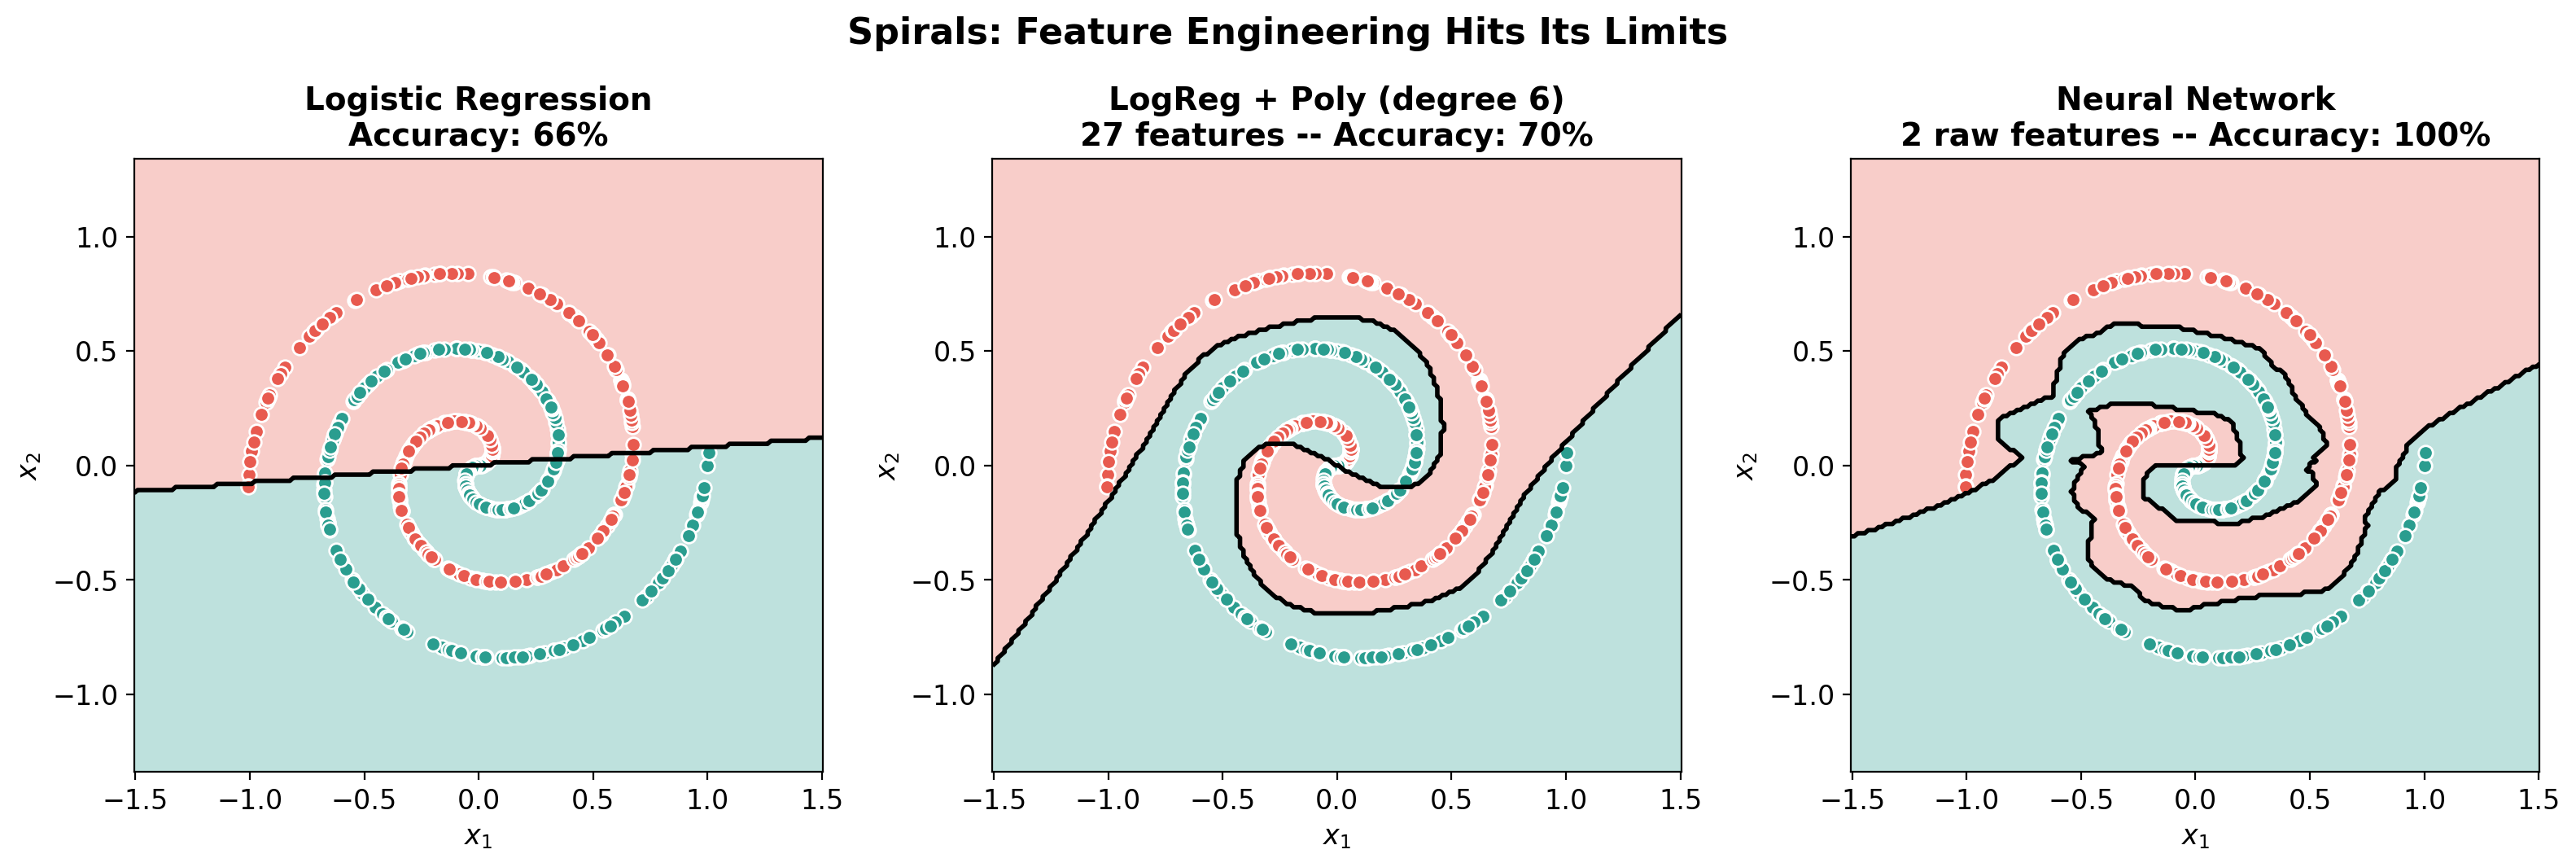

Even with 27 polynomial features, logistic regression struggles.
The neural network learns the spiral boundary from just x1 and x2!

This is the real power: NNs handle patterns that no human would think to engineer.


In [21]:
# Decision boundary comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_decision_boundary(lr_spiral.predict, X_spiral, y_spiral,
    f'Logistic Regression\nAccuracy: {acc_lin:.0%}', ax=axes[0])

plot_decision_boundary(predict_spiral_poly, X_spiral, y_spiral,
    f'LogReg + Poly (degree 6)\n{X_spiral_poly.shape[1]} features -- Accuracy: {acc_poly:.0%}', ax=axes[1])

plot_decision_boundary(predict_nn_spiral, X_spiral, y_spiral,
    f'Neural Network\n2 raw features -- Accuracy: {acc_nn:.0%}', ax=axes[2])

plt.suptitle('Spirals: Feature Engineering Hits Its Limits', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Even with 27 polynomial features, logistic regression struggles.')
print('The neural network learns the spiral boundary from just x1 and x2!')
print('\nThis is the real power: NNs handle patterns that no human would think to engineer.')

---
## Part 4: Images -- Where Feature Engineering Really Falls Apart

For circles and spirals, a clever person *might* guess polar coordinates or high-degree polynomials.

But what about **images**? Before deep learning, computer vision relied on:
- **Pixel intensity** histograms
- **HOG** (Histogram of Oriented Gradients) -- edge directions
- **SIFT/SURF** -- local keypoints
- Manually designed for each task!

Let's see this on MNIST digit classification.

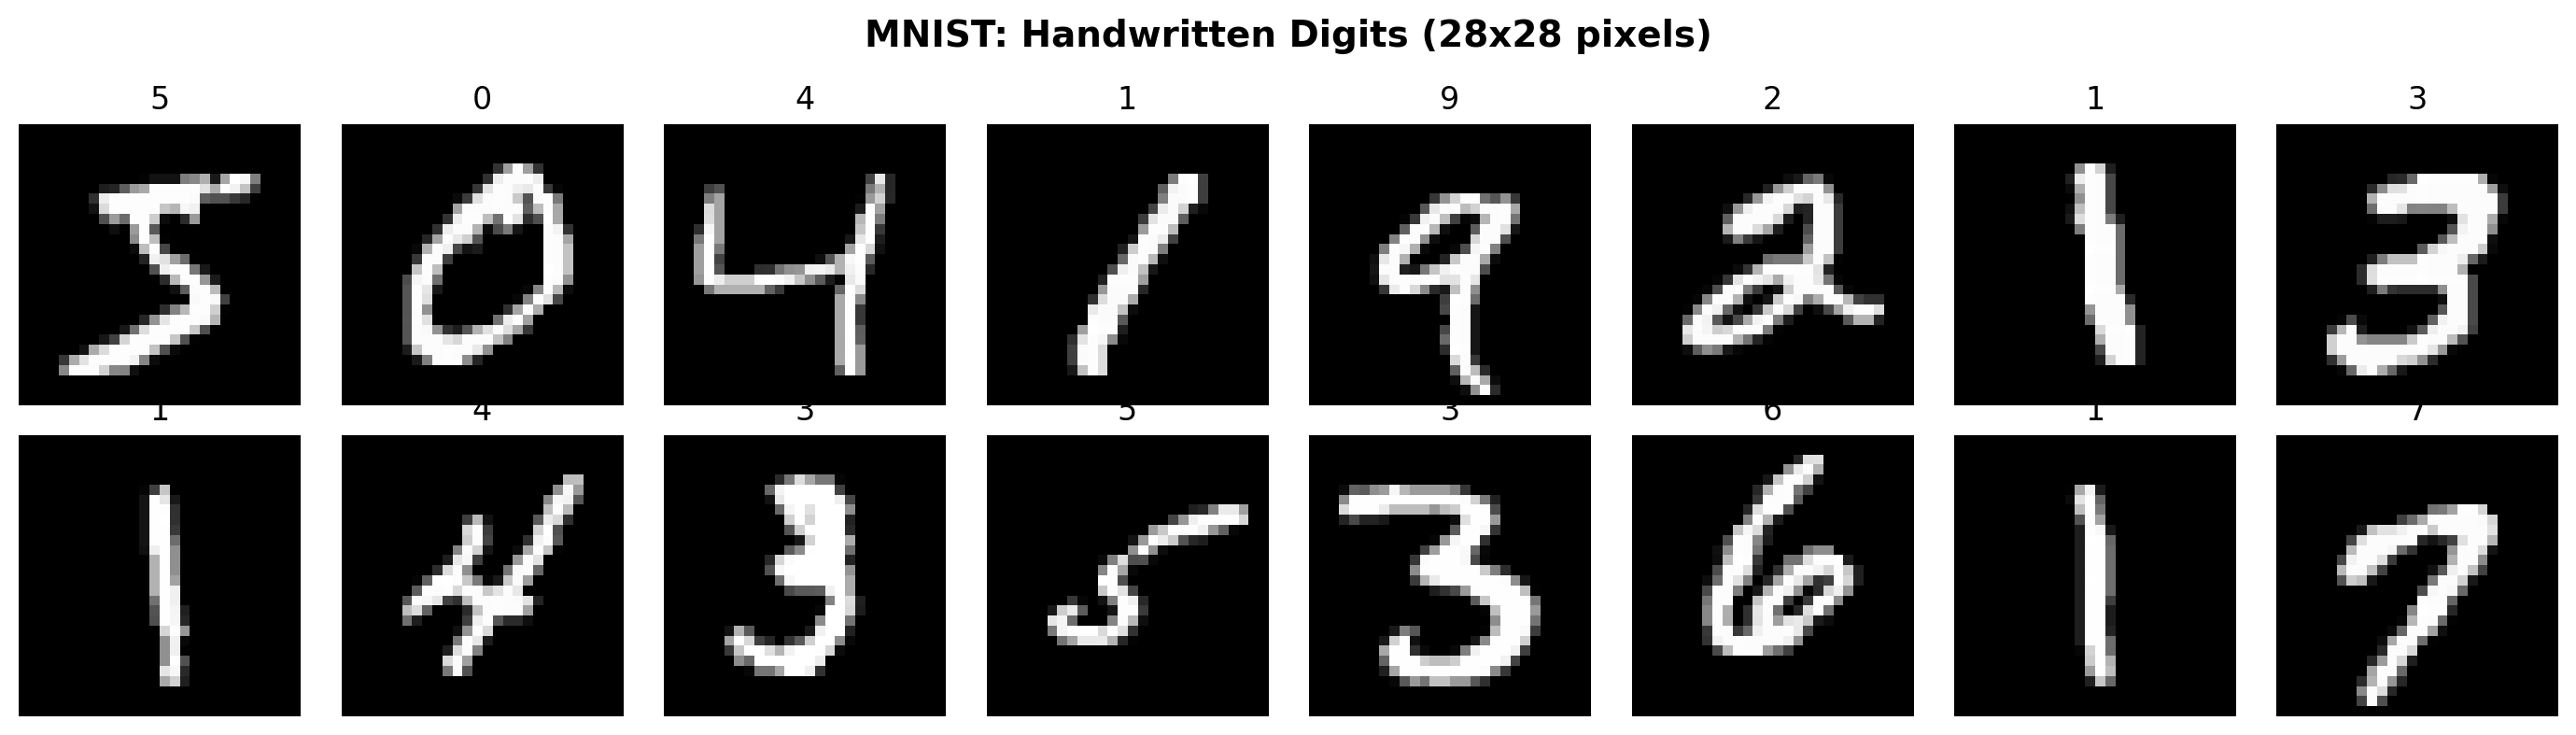

Training set: 60000 images, 28x28 pixels
Test set:     10000 images
Task: classify each image into one of 10 digits (0-9)


In [22]:
# Load MNIST
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score

mnist_train = datasets.MNIST('./data', train=True, download=True)
mnist_test = datasets.MNIST('./data', train=False, download=True)

# Convert to numpy
X_train_img = mnist_train.data.numpy()  # (60000, 28, 28)
y_train_img = mnist_train.targets.numpy()
X_test_img = mnist_test.data.numpy()
y_test_img = mnist_test.targets.numpy()

# Show some samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_img[i], cmap='gray')
    ax.set_title(f'{y_train_img[i]}', fontsize=12)
    ax.axis('off')
plt.suptitle('MNIST: Handwritten Digits (28x28 pixels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Training set: {X_train_img.shape[0]} images, {X_train_img.shape[1]}x{X_train_img.shape[2]} pixels')
print(f'Test set:     {X_test_img.shape[0]} images')
print(f'Task: classify each image into one of 10 digits (0-9)')

### Approach 1: Hand-Crafted Features + Logistic Regression

The "old way" -- before deep learning, you'd manually design features:
- **Raw pixels** flattened into a vector (784 numbers)
- **Intensity features**: mean brightness, how much ink, symmetry
- **HOG features**: captures edge directions (the standard pre-deep-learning feature)

Extracting hand-crafted features...
Hand-crafted features per image: 71
  - 15 engineered features (intensity, symmetry, gradients, quadrants)
  - 28 row profile + 28 column profile


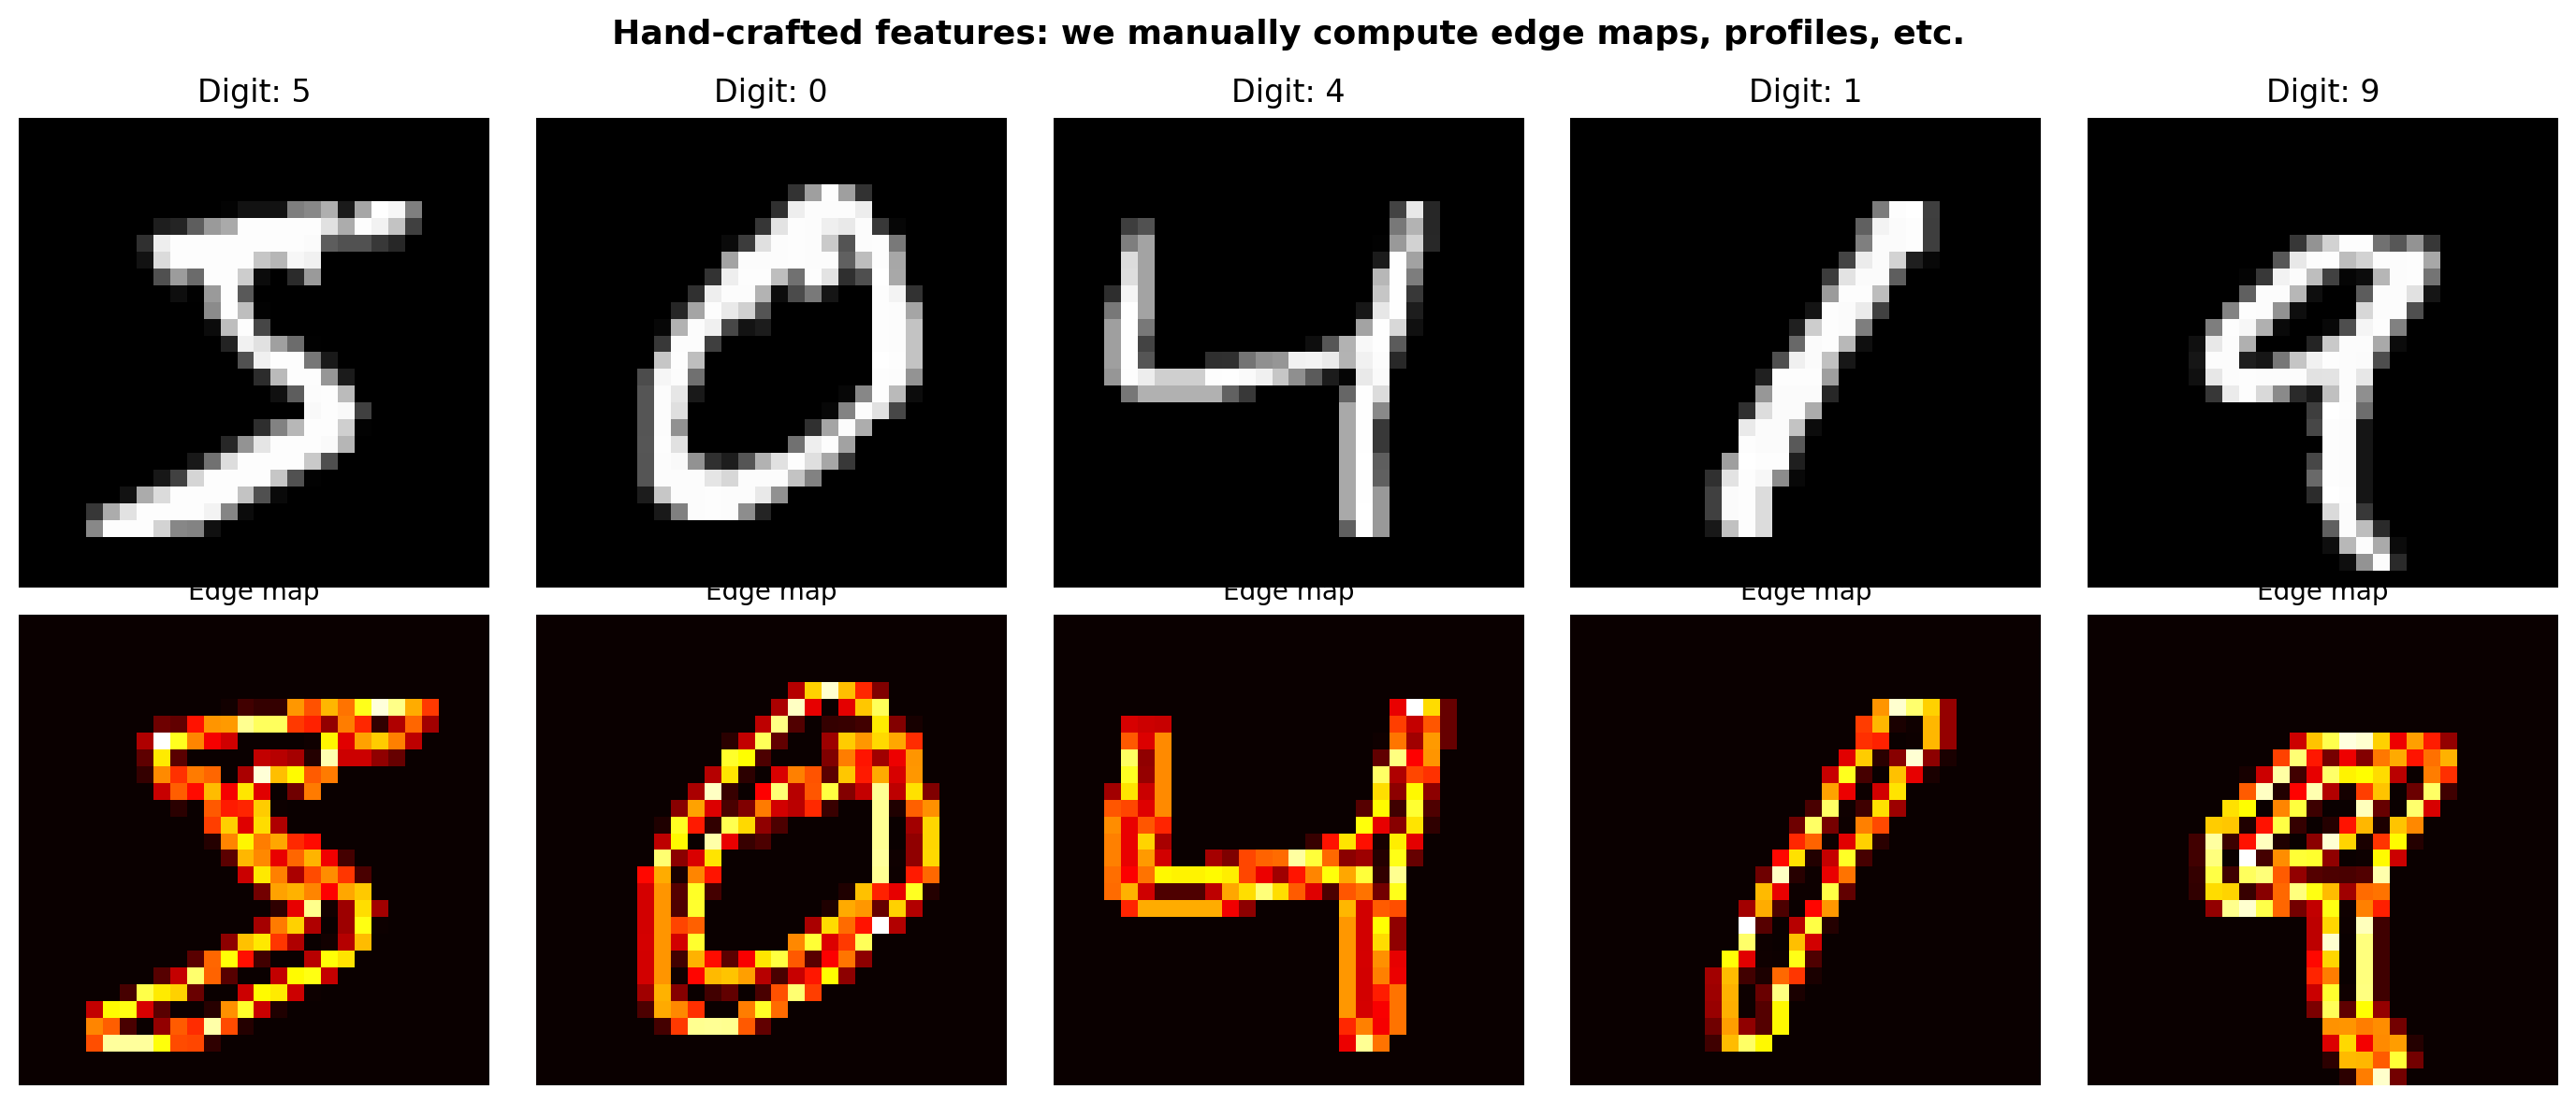

In [23]:
def extract_handcrafted_features(images):
    """Extract hand-designed features from digit images.
    This is what engineers did BEFORE deep learning."""
    features = []
    for img in images:
        img_f = img.astype(np.float32) / 255.0
        
        # 1. Basic intensity features
        mean_intensity = img_f.mean()
        std_intensity = img_f.std()
        ink_ratio = (img_f > 0.3).mean()  # fraction of "ink" pixels
        
        # 2. Spatial features -- where is the ink?
        top_half = img_f[:14, :].mean()
        bottom_half = img_f[14:, :].mean()
        left_half = img_f[:, :14].mean()
        right_half = img_f[:, 14:].mean()
        vertical_symmetry = np.abs(top_half - bottom_half)
        horizontal_symmetry = np.abs(left_half - right_half)
        
        # 3. Quadrant features
        q1 = img_f[:14, :14].mean()
        q2 = img_f[:14, 14:].mean()
        q3 = img_f[14:, :14].mean()
        q4 = img_f[14:, 14:].mean()
        
        # 4. Simple edge features (horizontal & vertical gradients)
        grad_h = np.abs(np.diff(img_f, axis=1)).mean()
        grad_v = np.abs(np.diff(img_f, axis=0)).mean()
        
        # 5. Profile features -- project onto axes
        row_profile = img_f.mean(axis=1)  # 28 values
        col_profile = img_f.mean(axis=0)  # 28 values
        
        feat = [mean_intensity, std_intensity, ink_ratio,
                top_half, bottom_half, left_half, right_half,
                vertical_symmetry, horizontal_symmetry,
                q1, q2, q3, q4, grad_h, grad_v]
        feat.extend(row_profile)
        feat.extend(col_profile)
        features.append(feat)
    
    return np.array(features)

# Extract features
print('Extracting hand-crafted features...')
X_train_feat = extract_handcrafted_features(X_train_img)
X_test_feat = extract_handcrafted_features(X_test_img)
print(f'Hand-crafted features per image: {X_train_feat.shape[1]}')
print(f'  - 15 engineered features (intensity, symmetry, gradients, quadrants)')
print(f'  - 28 row profile + 28 column profile')

# Visualize what HOG-like features look like
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    img = X_train_img[i].astype(np.float32) / 255.0
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Digit: {y_train_img[i]}', fontsize=12)
    axes[0, i].axis('off')
    
    # Show gradient magnitude (edge map)
    gx = np.abs(np.diff(img, axis=1, prepend=0))
    gy = np.abs(np.diff(img, axis=0, prepend=0))
    edges = np.sqrt(gx**2 + gy**2)
    axes[1, i].imshow(edges, cmap='hot')
    axes[1, i].set_title('Edge map', fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Edges', fontsize=12)
plt.suptitle('Hand-crafted features: we manually compute edge maps, profiles, etc.', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# --- Model 1: Logistic Regression on raw pixels ---
X_train_flat = X_train_img.reshape(-1, 784).astype(np.float32) / 255.0
X_test_flat = X_test_img.reshape(-1, 784).astype(np.float32) / 255.0

print('Training logistic regression on raw pixels (784 features)...')
lr_pixels = LogisticRegression(max_iter=1000, solver='lbfgs')
lr_pixels.fit(X_train_flat, y_train_img)
acc_pixels = accuracy_score(y_test_img, lr_pixels.predict(X_test_flat))
print(f'  Test accuracy: {acc_pixels:.1%}')

# --- Model 2: Logistic Regression on hand-crafted features ---
print(f'\nTraining logistic regression on hand-crafted features ({X_train_feat.shape[1]} features)...')
lr_feat = LogisticRegression(max_iter=1000, solver='lbfgs')
lr_feat.fit(X_train_feat, y_train_img)
acc_feat = accuracy_score(y_test_img, lr_feat.predict(X_test_feat))
print(f'  Test accuracy: {acc_feat:.1%}')

Training logistic regression on raw pixels (784 features)...
  Test accuracy: 92.6%

Training logistic regression on hand-crafted features (71 features)...
  Test accuracy: 84.5%


### Approach 2: Simple CNN -- Let the Network Learn Its Own Features

Instead of us designing edge detectors, the CNN **learns** what patterns matter.

A convolution layer is like a tiny sliding window that learns to detect edges, curves, loops -- whatever helps classify the digit.

In [25]:
# Simple CNN -- just 3 layers, nothing fancy
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),  # 28x28 -> 28x28, 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 28x28 -> 14x14
            nn.Conv2d(16, 32, 3, padding=1), # 14x14 -> 14x14, 32 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
cnn = SimpleCNN()
n_params = sum(p.numel() for p in cnn.parameters())
print(f'CNN architecture:')
print(cnn)
print(f'\nTotal parameters: {n_params:,}')

CNN architecture:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 105,866


In [26]:
# Train the CNN
# Prepare data as tensors -- images need shape (N, 1, 28, 28)
X_train_cnn = torch.tensor(X_train_img, dtype=torch.float32).unsqueeze(1) / 255.0
y_train_cnn = torch.tensor(y_train_img, dtype=torch.long)
X_test_cnn = torch.tensor(X_test_img, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_cnn = torch.tensor(y_test_img, dtype=torch.long)

optimizer = optim.Adam(cnn.parameters(), lr=0.001)
loss_fn_ce = nn.CrossEntropyLoss()

# Train for 3 epochs using mini-batches
batch_size = 256
losses_cnn = []

for epoch in range(3):
    epoch_loss = 0
    n_batches = 0
    # Shuffle
    perm = torch.randperm(len(X_train_cnn))
    
    for i in range(0, len(X_train_cnn), batch_size):
        idx = perm[i:i+batch_size]
        X_batch = X_train_cnn[idx]
        y_batch = y_train_cnn[idx]
        
        pred = cnn(X_batch)
        loss = loss_fn_ce(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
        losses_cnn.append(loss.item())
    
    # Evaluate
    with torch.no_grad():
        # Test in batches to avoid memory issues
        correct = 0
        for i in range(0, len(X_test_cnn), 1000):
            preds = cnn(X_test_cnn[i:i+1000]).argmax(dim=1)
            correct += (preds == y_test_cnn[i:i+1000]).sum().item()
        acc_cnn = correct / len(y_test_cnn)
    
    print(f'Epoch {epoch+1}/3 -- Loss: {epoch_loss/n_batches:.4f} -- Test Accuracy: {acc_cnn:.1%}')

print(f'\nFinal CNN test accuracy: {acc_cnn:.1%}')

Epoch 1/3 -- Loss: 0.4998 -- Test Accuracy: 94.6%
Epoch 2/3 -- Loss: 0.1225 -- Test Accuracy: 97.5%
Epoch 3/3 -- Loss: 0.0792 -- Test Accuracy: 98.0%

Final CNN test accuracy: 98.0%


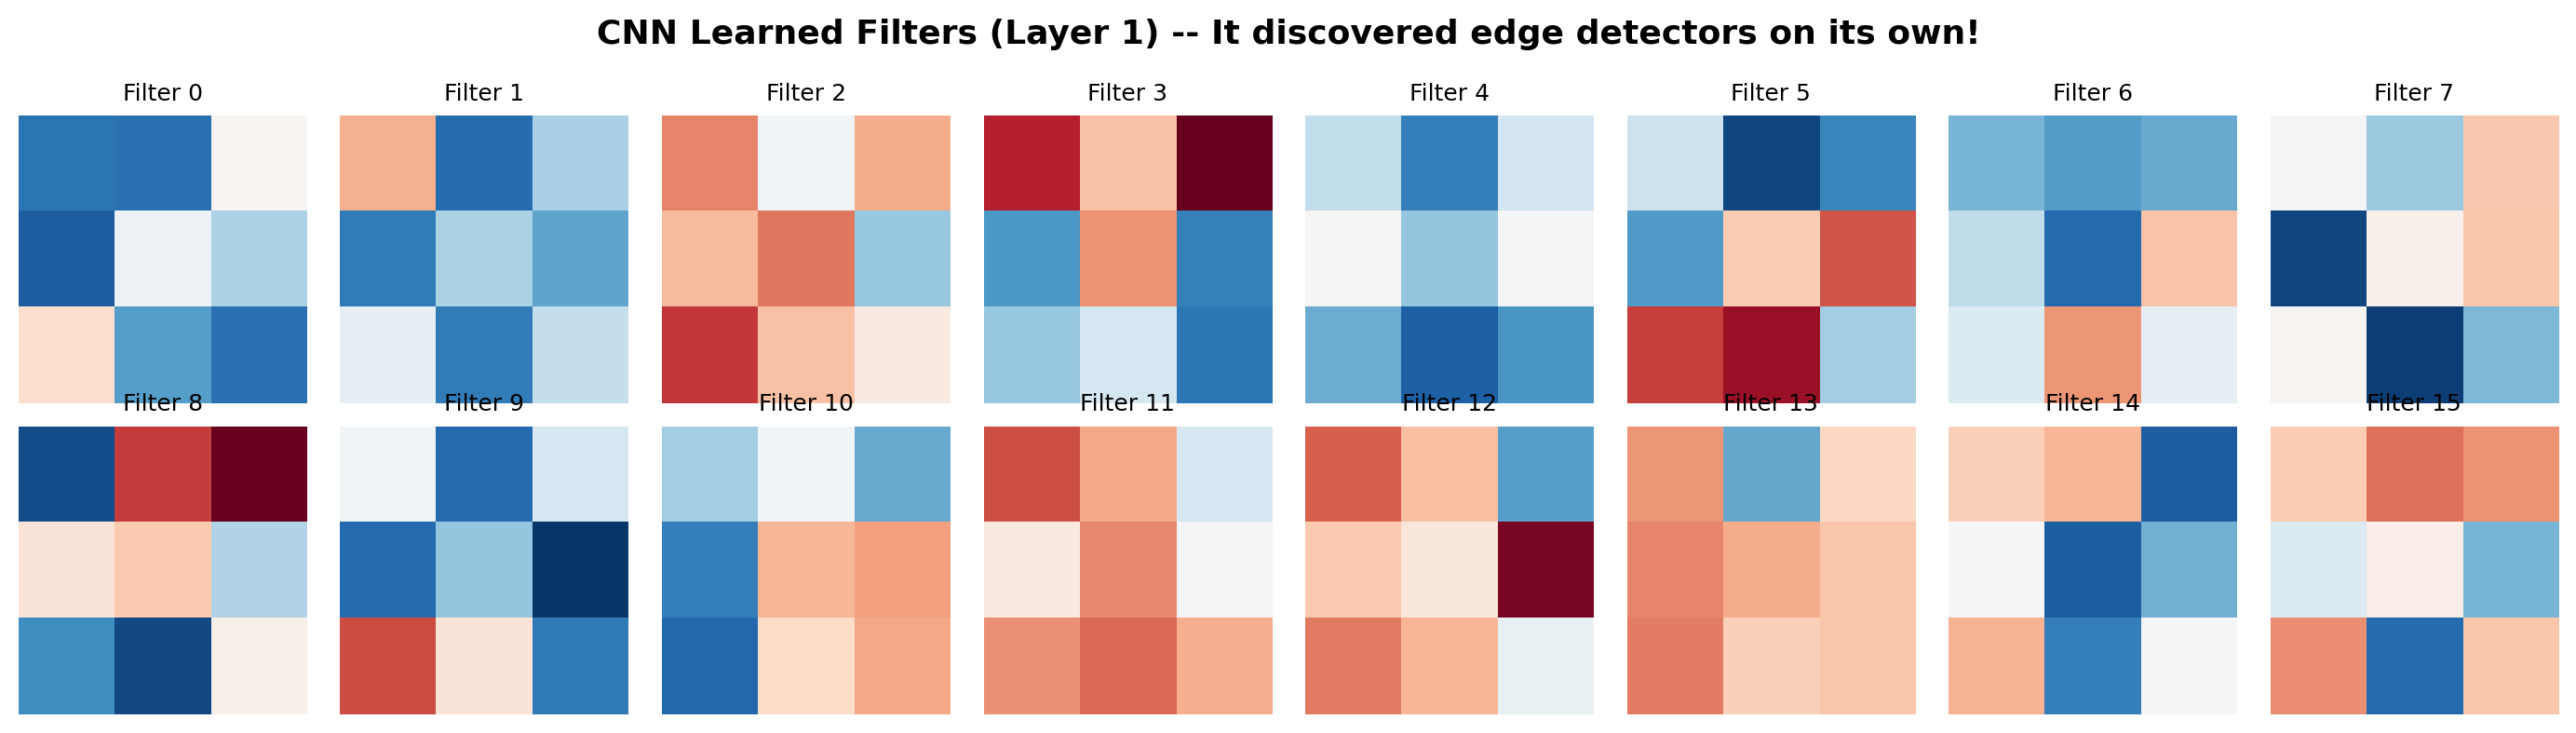

These filters detect edges, corners, and gradients.
We never told the CNN to look for edges -- it figured it out from the data!


In [27]:
# What did the CNN learn? Visualize the first-layer filters
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
filters = cnn.features[0].weight.data.numpy()  # (16, 1, 3, 3)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters[i, 0], cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.set_title(f'Filter {i}', fontsize=9)
    ax.axis('off')
plt.suptitle('CNN Learned Filters (Layer 1) -- It discovered edge detectors on its own!', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('These filters detect edges, corners, and gradients.')
print('We never told the CNN to look for edges -- it figured it out from the data!')

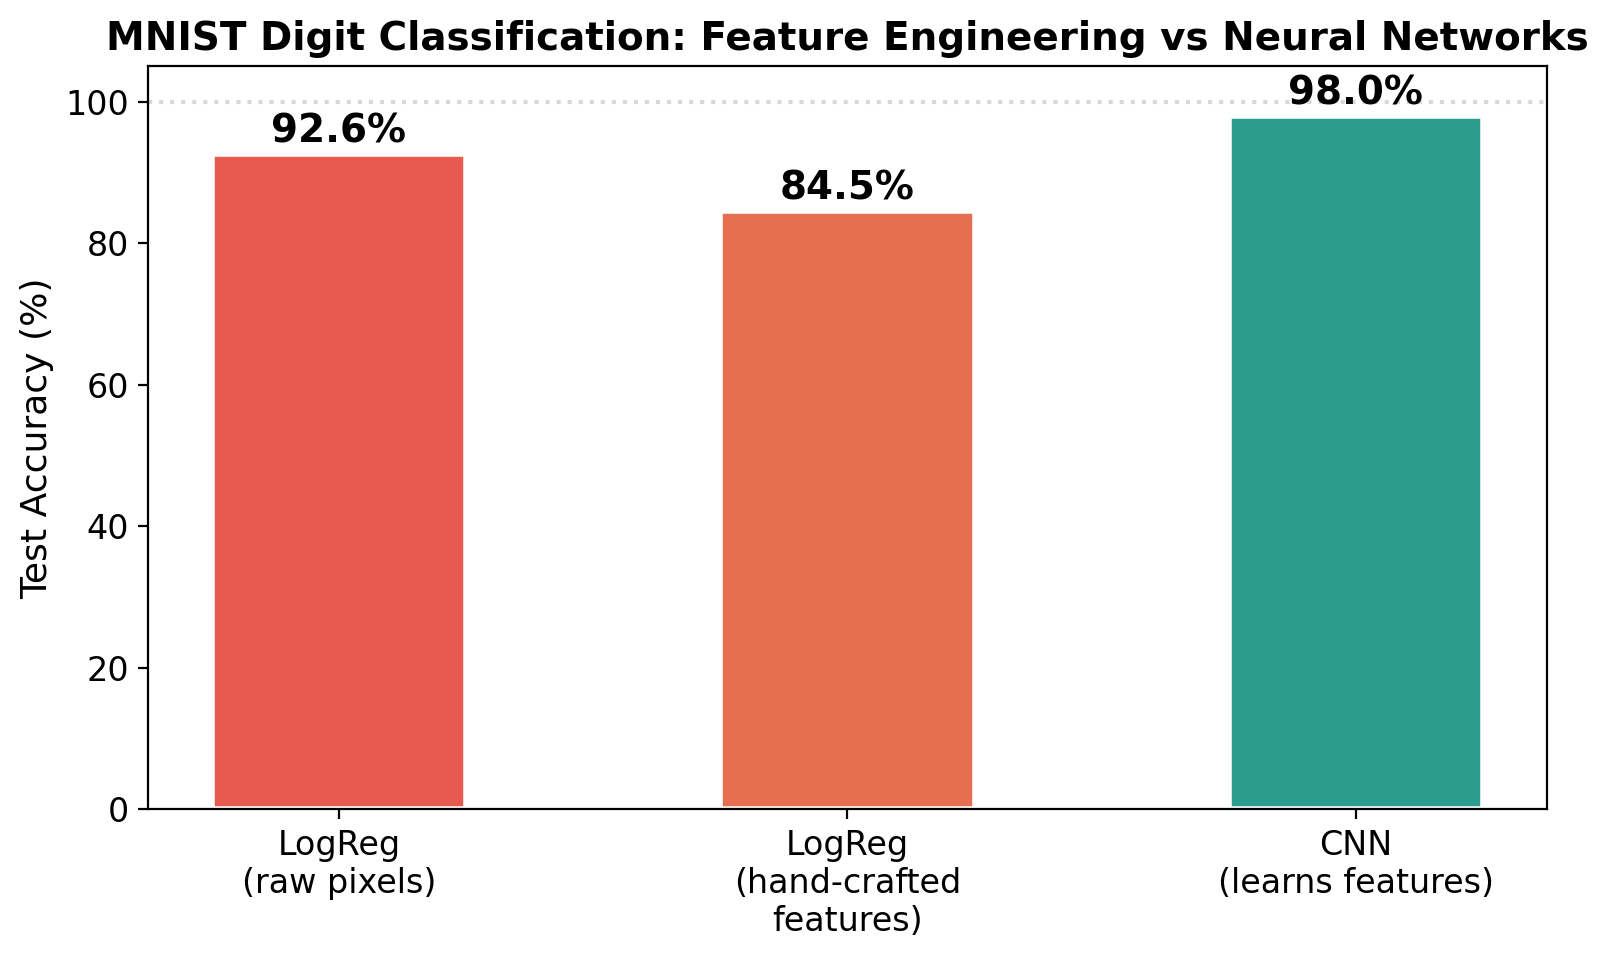

Logistic Regression (784 raw pixels):        92.6%
Logistic Regression (71 hand-crafted features): 84.5%
Simple CNN (learns its own features):        98.0%

The CNN beats both -- and we spent ZERO time designing features!


In [28]:
# The big comparison -- bar chart
models = ['LogReg\n(raw pixels)', 'LogReg\n(hand-crafted\nfeatures)', 'CNN\n(learns features)']
accs = [acc_pixels, acc_feat, acc_cnn]
colors = ['#e85a4f', '#e76f51', '#2a9d8f']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, [a * 100 for a in accs], color=colors, edgecolor='white', linewidth=2, width=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('MNIST Digit Classification: Feature Engineering vs Neural Networks', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Logistic Regression (784 raw pixels):        {acc_pixels:.1%}')
print(f'Logistic Regression ({X_train_feat.shape[1]} hand-crafted features): {acc_feat:.1%}')
print(f'Simple CNN (learns its own features):        {acc_cnn:.1%}')
print()
print('The CNN beats both -- and we spent ZERO time designing features!')

---
## The Full Picture

| Problem | Feature Engineering | Neural Network |
|---------|-------------------|----------------|
| Circles (2D) | Polynomial degree 2 -- **works** (easy to guess) | MLP -- **works** |
| Spirals (2D) | Polynomial degree 6 -- **struggles** | MLP -- **works** |
| Sine wave (1D) | Polynomial degree 5 -- **works** (if you guess right) | MLP -- **works** |
| Digits (images) | Intensity + edges + profiles -- **OK** (~91%) | CNN -- **great** (~99%) |

**The pattern:**
- Simple problems: feature engineering can match neural networks
- Complex problems: feature engineering breaks down; neural networks scale
- Images, audio, text: forget manual features -- neural networks dominate

**This is the paradigm shift:**

> Old way: Human designs features → simple model
>
> New way: Raw data → neural network learns everything

The hidden layers of a neural network **are** the feature engineering -- learned from data instead of designed by hand.